## 0. Imports

In [1]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.api import OLS, add_constant
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LassoCV, Lasso
from scipy import stats
from scipy.optimize import curve_fit

import altair as alt
alt.data_transformers.disable_max_rows()

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 20)

## 1. Configuration

> **Edit this cell to change variables, shock sizes, or asset groups.**

In [2]:
# ── Data path ────────────────────────────────────────────────
DATA_PATH = '../data/'

## 2. Data Loading & Preparation

Run once. Produces `regr_pool_users` — the master dataset used by both crypto and stablecoin sections.

In [3]:
# ── Load raw files ───────────────────────────────────────────
print("Loading data...")

dr = pd.read_csv(DATA_PATH + 'liquidation_pools_real_mul.csv')

dr_real = pd.read_csv(DATA_PATH + 'financialDailySnapshots.csv')


Loading data...


In [4]:
dr

,date,multiplier,symbol,C,D,T,E,Cp,Dp,Tp,B,Ep,liquidated_nbd,liquidated_bd,seized_nbd,seized_bd
0,2020-01-01,1.0,cBAT,8.586829e+05,6.524671e+04,7.937256e+05,2.894789e+02,8.586829e+05,6.524576e+04,7.937266e+05,0.000000,2.894789e+02,9.515342e-01,0.000000,1.942151e-07,0.000000
1,2020-01-01,1.0,cDAI,1.890544e+07,8.973783e+06,1.022663e+07,2.949695e+05,1.890544e+07,8.973783e+06,1.022663e+07,0.000000,2.949695e+05,0.000000e+00,0.000000,0.000000e+00,0.000000
2,2020-01-01,1.0,cETH,4.581498e+07,3.161124e+05,4.550053e+07,1.660012e+03,4.581498e+07,3.161124e+05,4.550052e+07,0.000000,1.660012e+03,2.502704e-12,0.000000,9.262815e-01,0.000000
3,2020-01-01,1.0,cREP,1.318560e+07,5.142933e+04,1.313436e+07,1.868850e+02,1.318560e+07,5.142933e+04,1.313436e+07,0.000000,1.868850e+02,0.000000e+00,0.000000,0.000000e+00,0.000000
4,2020-01-01,1.0,cSAI,5.763611e+06,2.085738e+06,3.729734e+06,5.186084e+04,5.763611e+06,2.085738e+06,3.729734e+06,0.000000,5.186084e+04,3.650534e-01,0.000000,5.220556e-01,0.000020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
900464,2024-06-15,10.0,cUSDP,4.407511e+05,4.361392e+05,2.015853e+04,1.554660e+04,4.407502e+05,4.358707e+05,2.038545e+04,40.588088,1.550601e+04,1.779158e+02,49.931015,9.323244e-01,0.000000
900465,2024-06-15,10.0,cUSDT,2.004420e+08,1.621348e+08,4.747758e+07,9.170308e+06,2.004416e+08,1.621143e+08,4.748217e+07,15416.288447,9.154892e+06,1.551634e+03,3478.302638,3.067564e+02,136.473710
900466,2024-06-15,10.0,cWBTC,3.384425e+08,1.270772e+06,3.371735e+08,1.853244e+03,3.384408e+08,1.263091e+06,3.371755e+08,4077.748935,0.000000e+00,1.296990e+03,2306.087695,6.325203e+02,1044.926628
900467,2024-06-15,10.0,cYFI,1.199088e+05,2.726224e+01,1.281929e+05,8.311349e+03,1.194108e+05,2.280765e+01,1.276991e+05,0.203125,8.311146e+03,3.191847e+00,1.059609,4.132119e+02,84.822217


In [5]:
dr_real

,blockNumber,cumulativeBorrowUSD,cumulativeDepositUSD,cumulativeLiquidateUSD,cumulativeProtocolSideRevenueUSD,cumulativeSupplySideRevenueUSD,cumulativeTotalRevenueUSD,dailyBorrowUSD,dailyDepositUSD,dailyLiquidateUSD,...,mintedTokenSupplies,protocolControlledValueUSD,timestamp,totalBorrowBalanceUSD,totalDepositBalanceUSD,totalValueLockedUSD,protocol.id,protocol.name,protocol.network,date
0,9198222.0,1.685808e+08,6.713015e+08,1.096366e+07,2.141636e+05,2.211154e+06,2.425317e+06,1.015658e+05,2.329829e+06,34.602013,...,NaN,NaN,1.577923e+09,2.654840e+07,1.204582e+08,1.204582e+08,0x3d9819210a31b4961b30ef54be2aed79b9c9cd3b,Compound v2,MAINNET,2020-01-01
1,9203915.0,1.686820e+08,6.742589e+08,1.098349e+07,2.146006e+05,2.215849e+06,2.430450e+06,1.012033e+05,2.957419e+06,19831.923615,...,NaN,NaN,1.578010e+09,2.656613e+07,1.203144e+08,1.203144e+08,0x3d9819210a31b4961b30ef54be2aed79b9c9cd3b,Compound v2,MAINNET,2020-01-02
2,9210391.0,1.706705e+08,6.799749e+08,1.112524e+07,2.151033e+05,2.221282e+06,2.436386e+06,1.988501e+06,5.716069e+06,141749.719758,...,NaN,NaN,1.578095e+09,2.683982e+07,1.232730e+08,1.232730e+08,0x3d9819210a31b4961b30ef54be2aed79b9c9cd3b,Compound v2,MAINNET,2020-01-03
3,9216968.0,1.722911e+08,6.846213e+08,1.112525e+07,2.156155e+05,2.226768e+06,2.442384e+06,1.620543e+06,4.644390e+06,16.212282,...,NaN,NaN,1.578182e+09,2.679821e+07,1.241529e+08,1.241529e+08,0x3d9819210a31b4961b30ef54be2aed79b9c9cd3b,Compound v2,MAINNET,2020-01-04
4,9223484.0,1.725265e+08,6.858689e+08,1.113572e+07,2.161249e+05,2.232240e+06,2.448365e+06,2.354306e+05,1.247600e+06,10468.961428,...,NaN,NaN,1.578269e+09,2.693420e+07,1.251104e+08,1.251104e+08,0x3d9819210a31b4961b30ef54be2aed79b9c9cd3b,Compound v2,MAINNET,2020-01-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1623,20072002.0,1.016852e+11,3.086132e+11,1.098031e+09,6.044544e+07,4.427548e+08,5.032002e+08,2.061520e+05,1.095294e+06,6204.995179,...,NaN,NaN,1.718150e+09,2.869278e+08,1.138741e+09,1.138741e+09,0x3d9819210a31b4961b30ef54be2aed79b9c9cd3b,Compound v2,MAINNET,2024-06-11
1624,20078582.0,1.016860e+11,3.086228e+11,1.098031e+09,6.046054e+07,4.428099e+08,5.032705e+08,8.942400e+05,9.585418e+06,440.168736,...,NaN,NaN,1.718230e+09,2.876925e+08,1.145156e+09,1.145156e+09,0x3d9819210a31b4961b30ef54be2aed79b9c9cd3b,Compound v2,MAINNET,2024-06-12
1625,20086155.0,1.016863e+11,3.086375e+11,1.098031e+09,6.048051e+07,4.428967e+08,5.033772e+08,2.541993e+05,1.472900e+07,0.000000,...,NaN,NaN,1.718321e+09,2.878419e+08,1.132024e+09,1.132024e+09,0x3d9819210a31b4961b30ef54be2aed79b9c9cd3b,Compound v2,MAINNET,2024-06-13
1626,20093246.0,1.016883e+11,3.086440e+11,1.098047e+09,6.049973e+07,4.429691e+08,5.034688e+08,2.014348e+06,6.553668e+06,15629.383111,...,NaN,NaN,1.718407e+09,2.898455e+08,1.139164e+09,1.139164e+09,0x3d9819210a31b4961b30ef54be2aed79b9c9cd3b,Compound v2,MAINNET,2024-06-14


In [6]:
dr_real['liq_to_tvl'] = dr_real['dailyLiquidateUSD'] / dr_real['totalValueLockedUSD']


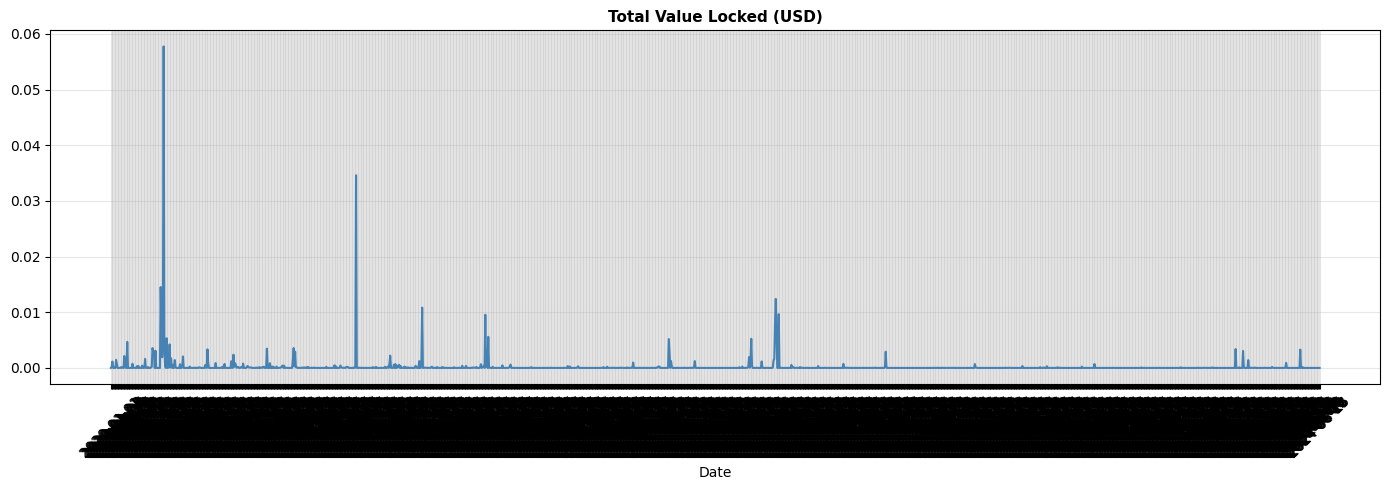

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(dr_real['date'], dr_real['liq_to_tvl'],
        color='steelblue', linewidth=1.5)

ax.set_title('Total Value Locked (USD)', fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
top100 = dr_real.nlargest(100, 'liq_to_tvl')[['date', 'liq_to_tvl', 'dailyLiquidateUSD', 'totalValueLockedUSD']]
print(top100)


            date  liq_to_tvl  dailyLiquidateUSD  totalValueLockedUSD
71    2020-03-12    0.057756       6.216734e+06         1.076387e+08
330   2020-11-26    0.034603       1.086339e+08         3.139474e+09
67    2020-03-08    0.014529       2.566735e+06         1.766680e+08
895   2022-06-14    0.012398       4.907927e+07         3.958546e+09
419   2021-02-23    0.010834       9.447844e+07         8.720247e+09
...          ...         ...                ...                  ...
1227  2023-05-12    0.000338       5.946384e+05         1.760146e+09
615   2021-09-07    0.000332       6.748928e+06         2.030904e+10
952   2022-08-10    0.000328       1.328831e+06         4.048272e+09
35    2020-02-05    0.000304       5.017474e+04         1.651562e+08
863   2022-05-13    0.000301       1.762474e+06         5.858017e+09

[100 rows x 4 columns]


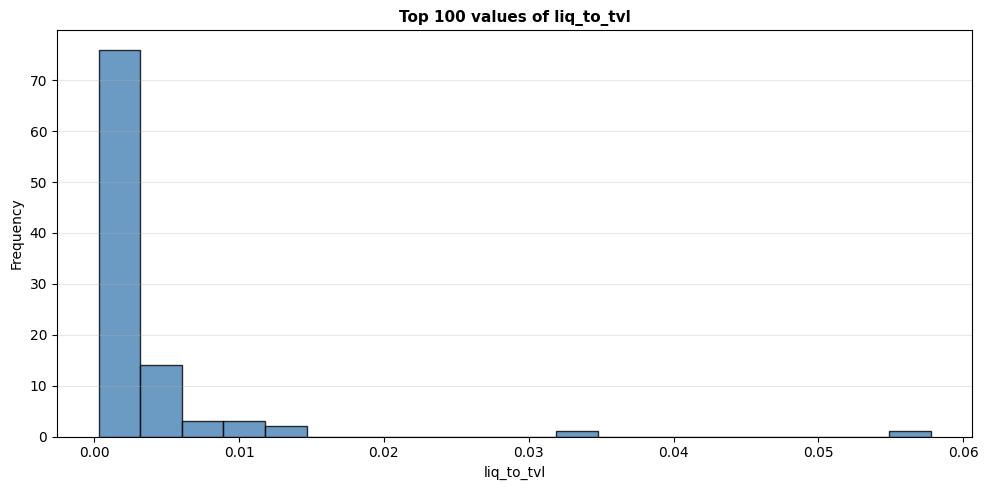

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(top100['liq_to_tvl'], bins=20, color='steelblue', alpha=0.8, edgecolor='black')

ax.set_title('Top 100 values of liq_to_tvl', fontsize=11, fontweight='bold')
ax.set_xlabel('liq_to_tvl')
ax.set_ylabel('Frequency')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [10]:
print((dr_real['liq_to_tvl'] >= 0.0025).sum())

30


In [11]:
dr_real[dr_real['liq_to_tvl'] >= 0.0025][['date', 'liq_to_tvl', 'dailyLiquidateUSD', 'totalValueLockedUSD']]

,date,liq_to_tvl,dailyLiquidateUSD,totalValueLockedUSD
22,2020-01-23,0.004672,6.293089e+05,1.347003e+08
56,2020-02-26,0.003568,6.931922e+05,1.943063e+08
57,2020-02-27,0.002876,5.818755e+05,2.023546e+08
58,2020-02-28,0.002939,6.017022e+05,2.047269e+08
60,2020-03-01,0.003080,6.219976e+05,2.019775e+08
67,2020-03-08,0.014529,2.566735e+06,1.766680e+08
68,2020-03-09,0.006983,1.181571e+06,1.692158e+08
70,2020-03-11,0.005877,8.785697e+05,1.494861e+08
71,2020-03-12,0.057756,6.216734e+06,1.076387e+08
72,2020-03-13,0.003348,4.096688e+05,1.223777e+08


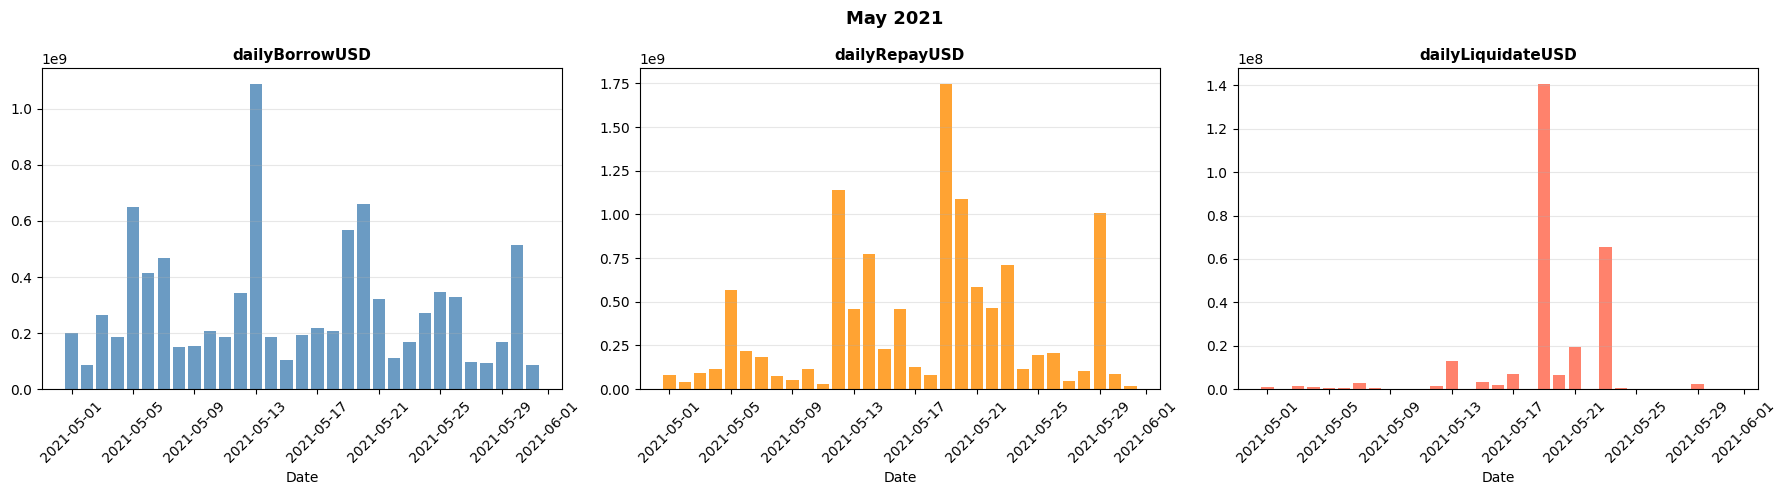

In [12]:
dr_real['date'] = pd.to_datetime(dr_real['date'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cols   = ['dailyBorrowUSD', 'dailyRepayUSD', 'dailyLiquidateUSD']
colors = ['steelblue', 'darkorange', 'tomato']

df_may = dr_real[
    (dr_real['date'].dt.year == 2021) &
    (dr_real['date'].dt.month == 5)
]

for ax, col, color in zip(axes, cols, colors):
    ax.bar(df_may['date'], df_may[col], color=color, alpha=0.8, width=0.8)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('May 2021', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
dr['date'] = pd.to_datetime(dr['date'])

df_may = dr[
    (dr['date'].dt.year == 2021) &
    (dr['date'].dt.month == 5) &
    (dr['multiplier'] == 1.75)
]

df_may_daily = df_may.groupby('date').sum().reset_index()


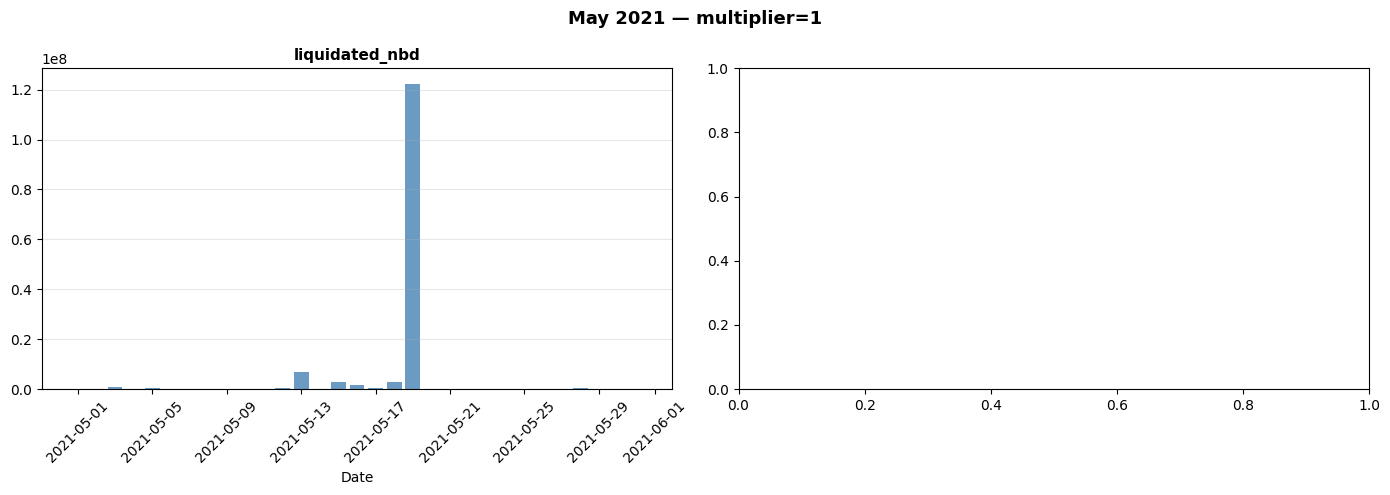

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, color in zip(axes,
                           ['liquidated_nbd'],
                           ['steelblue']):
    ax.bar(df_may_daily['date'], df_may_daily[col], color=color, alpha=0.8, width=0.8)
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Date')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('May 2021 — multiplier=1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [15]:
print('dailyLiquidateUSD' in dr.columns)
print('dailyLiquidateUSD' in dr_real.columns)


False
True


In [16]:
df_combined = pd.merge(
    dr.groupby(['date', 'multiplier'])[['liquidated_nbd']].sum().reset_index(),
    dr_real[['date', 'dailyLiquidateUSD']],
    on='date', how='outer'
).sort_values(['date', 'multiplier'])

print(df_combined.shape)
print(df_combined.head())


(60236, 4)
        date  multiplier  liquidated_nbd  dailyLiquidateUSD
0 2020-01-01        1.00        1.316670          34.602013
1 2020-01-01        1.25        1.442252          34.602013
2 2020-01-01        1.50        1.588346          34.602013
3 2020-01-01        1.75        1.737486          34.602013
4 2020-01-01        2.00        0.803977          34.602013


In [17]:
dr['date'] = pd.to_datetime(dr['date'])

df_may_all = dr[
    (dr['date'].dt.year == 2022) &
    (dr['date'].dt.month == 5)
]

may_by_multiplier = {
    mult: df_may_all[df_may_all['multiplier'] == mult].copy()
    for mult in sorted(df_may_all['multiplier'].unique())
}

# Check
for mult, df in may_by_multiplier.items():
    print(f"multiplier={mult}: N={len(df)}")


multiplier=1.0: N=558
multiplier=1.25: N=558
multiplier=1.5: N=558
multiplier=1.75: N=558
multiplier=2.0: N=558
multiplier=2.25: N=558
multiplier=2.5: N=558
multiplier=2.75: N=558
multiplier=3.0: N=558
multiplier=3.25: N=558
multiplier=3.5: N=558
multiplier=3.75: N=558
multiplier=4.0: N=558
multiplier=4.25: N=558
multiplier=4.5: N=558
multiplier=4.75: N=558
multiplier=5.0: N=558
multiplier=5.25: N=558
multiplier=5.5: N=558
multiplier=5.75: N=558
multiplier=6.0: N=558
multiplier=6.25: N=558
multiplier=6.5: N=558
multiplier=6.75: N=558
multiplier=7.0: N=558
multiplier=7.25: N=558
multiplier=7.5: N=558
multiplier=7.75: N=558
multiplier=8.0: N=558
multiplier=8.25: N=558
multiplier=8.5: N=558
multiplier=8.75: N=558
multiplier=9.0: N=558
multiplier=9.25: N=558
multiplier=9.5: N=558
multiplier=9.75: N=558
multiplier=10.0: N=558


# MAY 2021

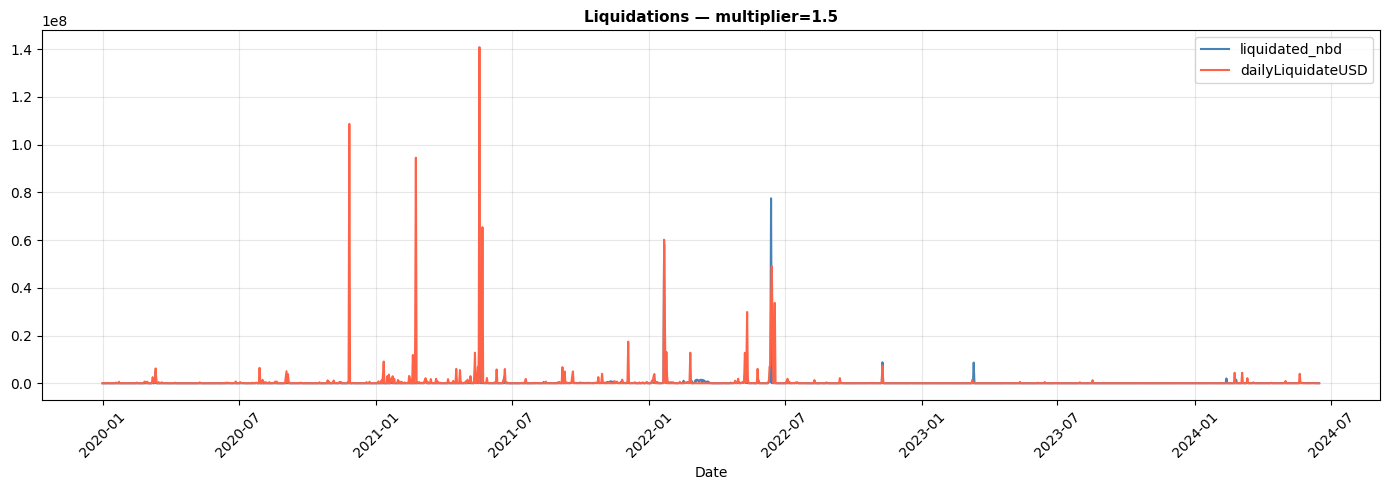

In [18]:
df_plot = df_combined[df_combined['multiplier'] == 1.5].sort_values('date')

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot['date'], df_plot['liquidated_nbd'],
        color='steelblue', linewidth=1.5, label='liquidated_nbd')
ax.plot(df_plot['date'], df_plot['dailyLiquidateUSD'],
        color='tomato', linewidth=1.5, label='dailyLiquidateUSD')

ax.set_title('Liquidations — multiplier=1.5', fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


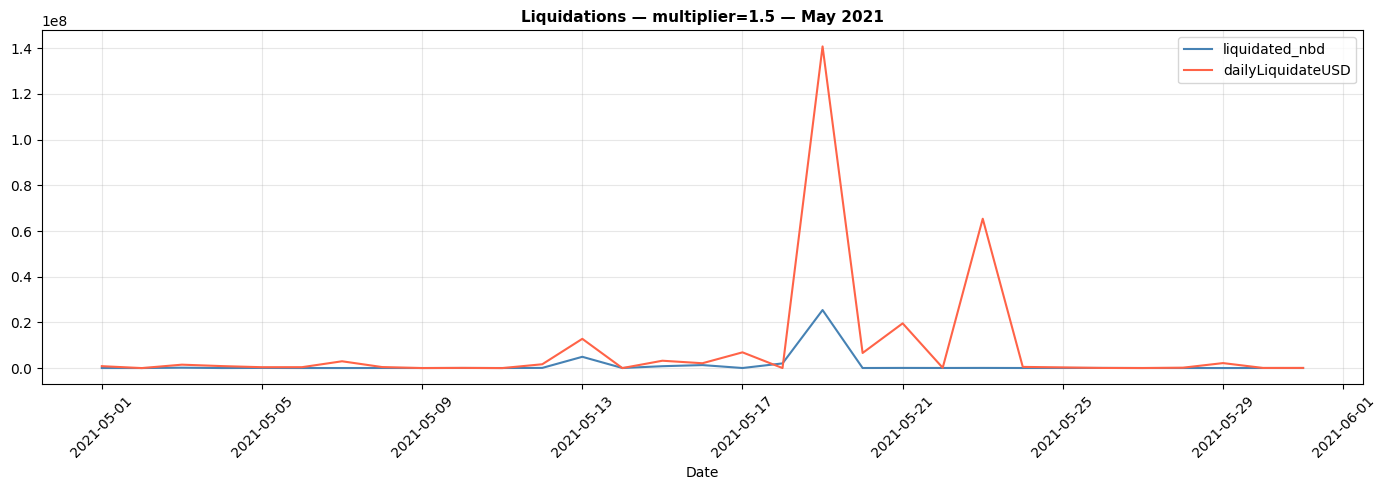

In [19]:
df_plot_may = df_plot[
    (df_plot['date'].dt.year == 2021) &
    (df_plot['date'].dt.month == 5)
]
df_plot = df_combined[df_combined['multiplier'] == 1.75].sort_values('date')


fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_plot_may['date'], df_plot_may['liquidated_nbd'],
        color='steelblue', linewidth=1.5, label='liquidated_nbd')
ax.plot(df_plot_may['date'], df_plot_may['dailyLiquidateUSD'],
        color='tomato', linewidth=1.5, label='dailyLiquidateUSD')

ax.set_title('Liquidations — multiplier=1.5 — May 2021', fontsize=11, fontweight='bold')

ax.set_xlabel('Date')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


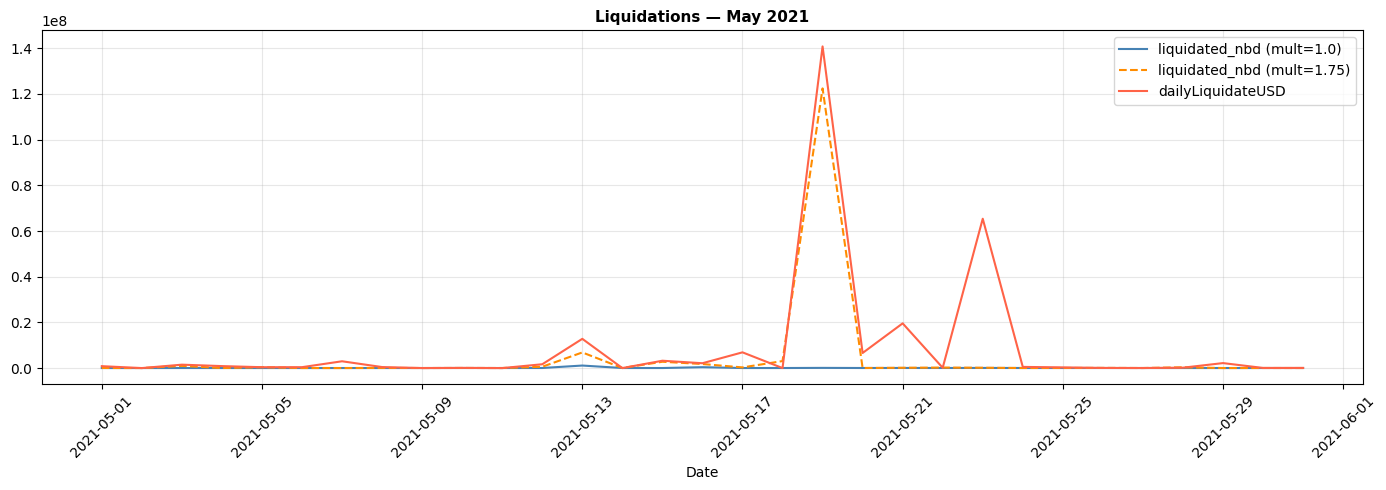

In [20]:
fig, ax = plt.subplots(figsize=(14, 5))

for mult, color, style in [(1.0, 'steelblue', '-'), (1.75, 'darkorange', '--')]:
    df_plot = df_combined[df_combined['multiplier'] == mult].sort_values('date')
    df_plot_may = df_plot[
        (df_plot['date'].dt.year == 2021) &
        (df_plot['date'].dt.month == 5)
    ]
    ax.plot(df_plot_may['date'], df_plot_may['liquidated_nbd'],
            color=color, linewidth=1.5, linestyle=style,
            label=f'liquidated_nbd (mult={mult})')

# dailyLiquidateUSD is the same regardless of multiplier
ax.plot(df_plot_may['date'], df_plot_may['dailyLiquidateUSD'],
        color='tomato', linewidth=1.5, label='dailyLiquidateUSD')

ax.set_title('Liquidations — May 2021', fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



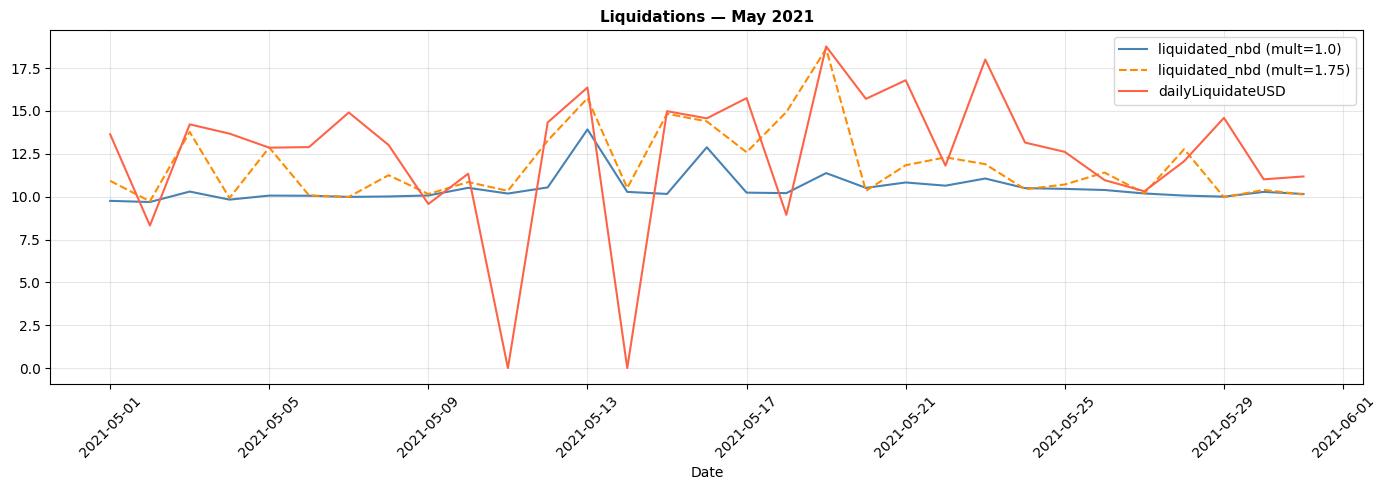

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))

for mult, color, style in [(1.0, 'steelblue', '-'), (1.75, 'darkorange', '--')]:
    df_plot = df_combined[df_combined['multiplier'] == mult].sort_values('date')
    df_plot_may = df_plot[
        (df_plot['date'].dt.year == 2021) &
        (df_plot['date'].dt.month == 5)
    ]
    ax.plot(df_plot_may['date'], np.log(df_plot_may['liquidated_nbd'] + 1),
        color=color, linewidth=1.5, linestyle=style,
        label=f'liquidated_nbd (mult={mult})')

ax.plot(df_plot_may['date'], np.log(df_plot_may['dailyLiquidateUSD'] + 1),
        color='tomato', linewidth=1.5, label='dailyLiquidateUSD')

ax.set_title('Liquidations — May 2021', fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# MAY 2022

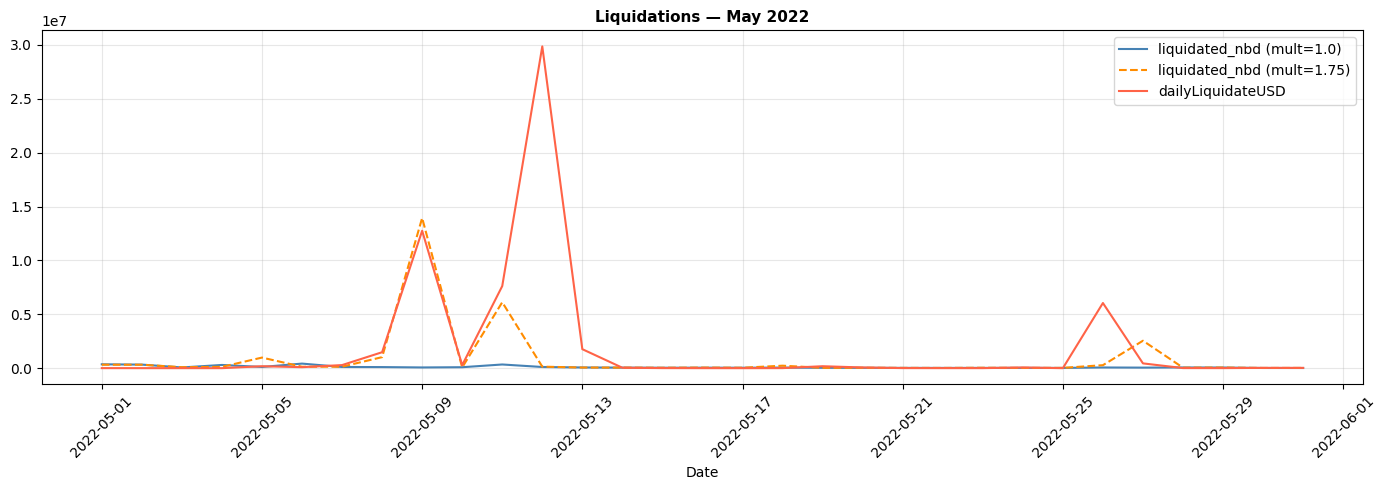

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))

for mult, color, style in [(1.0, 'steelblue', '-'), (1.75, 'darkorange', '--')]:
    df_plot = df_combined[df_combined['multiplier'] == mult].sort_values('date')
    df_plot_may = df_plot[
        (df_plot['date'].dt.year == 2022) &
        (df_plot['date'].dt.month == 5)
    ]
    ax.plot(df_plot_may['date'], df_plot_may['liquidated_nbd'],
            color=color, linewidth=1.5, linestyle=style,
            label=f'liquidated_nbd (mult={mult})')

# dailyLiquidateUSD is the same regardless of multiplier
ax.plot(df_plot_may['date'], df_plot_may['dailyLiquidateUSD'],
        color='tomato', linewidth=1.5, label='dailyLiquidateUSD')

ax.set_title('Liquidations — May 2022', fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# November 2022

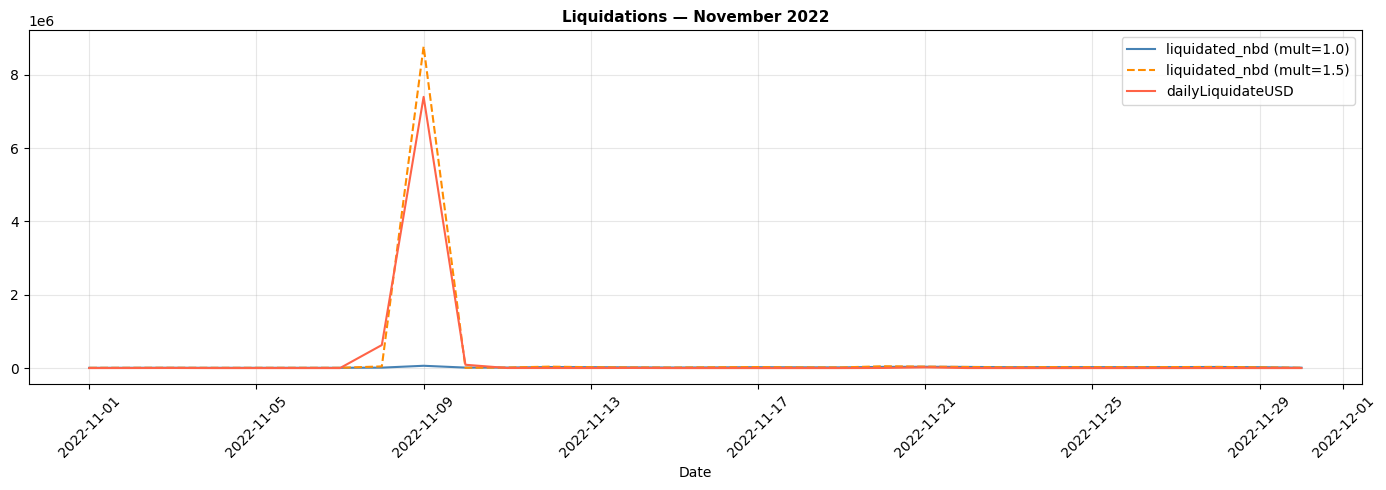

In [23]:
fig, ax = plt.subplots(figsize=(14, 5))

for mult, color, style in [(1.0, 'steelblue', '-'), (1.5, 'darkorange', '--')]:
    df_plot = df_combined[df_combined['multiplier'] == mult].sort_values('date')
    df_plot_may = df_plot[
        (df_plot['date'].dt.year == 2022) &
        (df_plot['date'].dt.month == 11)
    ]
    ax.plot(df_plot_may['date'], df_plot_may['liquidated_nbd'],
            color=color, linewidth=1.5, linestyle=style,
            label=f'liquidated_nbd (mult={mult})')

# dailyLiquidateUSD is the same regardless of multiplier
ax.plot(df_plot_may['date'], df_plot_may['dailyLiquidateUSD'],
        color='tomato', linewidth=1.5, label='dailyLiquidateUSD')

ax.set_title('Liquidations — November 2022', fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# MARCH 2023

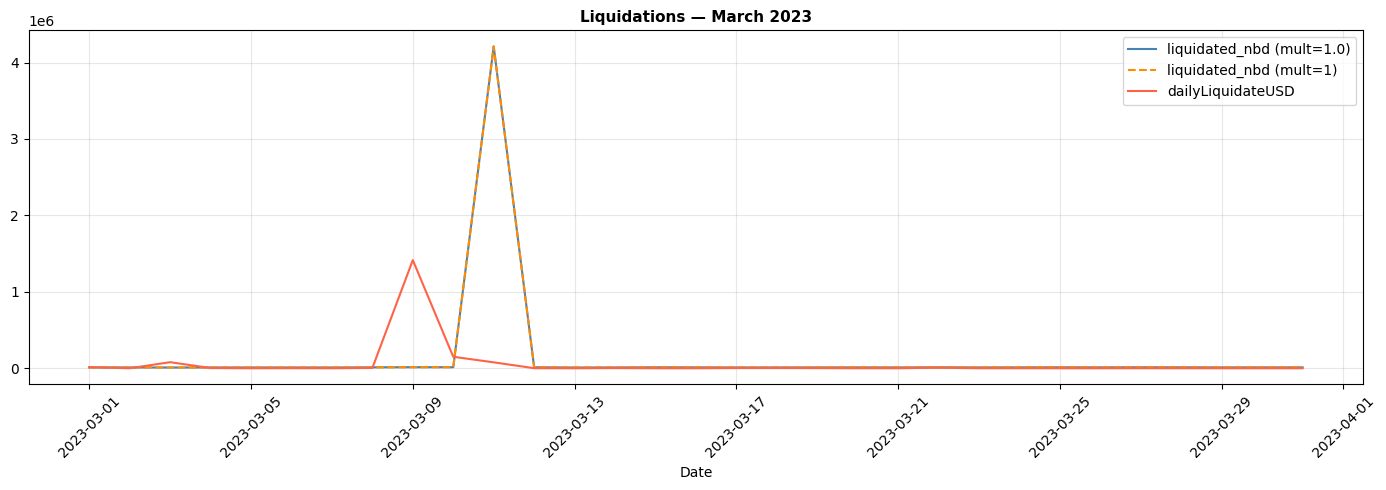

In [24]:
fig, ax = plt.subplots(figsize=(14, 5))

for mult, color, style in [(1.0, 'steelblue', '-'), (1, 'darkorange', '--')]:
    df_plot = df_combined[df_combined['multiplier'] == mult].sort_values('date')
    df_plot_may = df_plot[
        (df_plot['date'].dt.year == 2023) &
        (df_plot['date'].dt.month == 3)
    ]
    ax.plot(df_plot_may['date'], df_plot_may['liquidated_nbd'],
            color=color, linewidth=1.5, linestyle=style,
            label=f'liquidated_nbd (mult={mult})')

# dailyLiquidateUSD is the same regardless of multiplier
ax.plot(df_plot_may['date'], df_plot_may['dailyLiquidateUSD'],
        color='tomato', linewidth=1.5, label='dailyLiquidateUSD')

ax.set_title('Liquidations — March 2023', fontsize=11, fontweight='bold')
ax.set_xlabel('Date')
ax.legend()
ax.tick_params(axis='x', rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# CORRELATION

In [25]:
corr_by_multiplier = (df_combined
                      .groupby('multiplier')[['liquidated_nbd', 'dailyLiquidateUSD']]
                      .corr()
                      .unstack()['dailyLiquidateUSD']['liquidated_nbd']
                      .reset_index()
                      .rename(columns={'liquidated_nbd': 'correlation'}))

print(corr_by_multiplier)


    multiplier  correlation
0         1.00     0.030957
1         1.25     0.260900
2         1.50     0.399142
3         1.75     0.617403
4         2.00     0.626061
5         2.25     0.605238
6         2.50     0.605767
7         2.75     0.426683
8         3.00     0.439799
9         3.25     0.397829
10        3.50     0.346708
11        3.75     0.308690
12        4.00     0.295548
13        4.25     0.251699
14        4.50     0.250357
15        4.75     0.208289
16        5.00     0.264124
17        5.25     0.252911
18        5.50     0.276015
19        5.75     0.251684
20        6.00     0.222520
21        6.25     0.232030
22        6.50     0.221209
23        6.75     0.242642
24        7.00     0.232220
25        7.25     0.231242
26        7.50     0.230126
27        7.75     0.240899
28        8.00     0.237565
29        8.25     0.232736
30        8.50     0.081068
31        8.75     0.074788
32        9.00     0.081184
33        9.25     0.047111
34        9.50     0

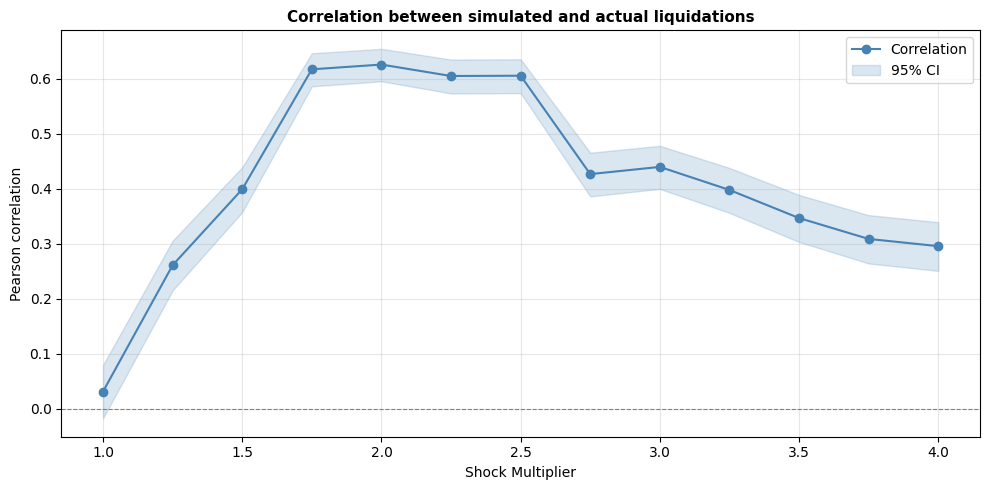

In [26]:
from scipy import stats

corr_data = []
for mult, df_m in df_combined.groupby('multiplier'):
    df_m = df_m[['liquidated_nbd', 'dailyLiquidateUSD']].dropna()
    n    = len(df_m)
    r    = df_m['liquidated_nbd'].corr(df_m['dailyLiquidateUSD'])

    # Fisher z-transformation for CI
    z     = np.arctanh(r)
    se    = 1 / np.sqrt(n - 3)
    ci_lo = np.tanh(z - 1.96 * se)
    ci_hi = np.tanh(z + 1.96 * se)

    corr_data.append({'multiplier': mult, 'corr': r,
                      'ci_lo': ci_lo, 'ci_hi': ci_hi, 'n': n})

corr_df = pd.DataFrame(corr_data).sort_values('multiplier')
corr_df_filtered = corr_df[(corr_df['multiplier'] >= 1) & (corr_df['multiplier'] <= 4)]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(corr_df_filtered['multiplier'], corr_df_filtered['corr'],
        color='steelblue', linewidth=1.5, marker='o', label='Correlation')
ax.fill_between(corr_df_filtered['multiplier'], corr_df_filtered['ci_lo'], corr_df_filtered['ci_hi'],
                alpha=0.2, color='steelblue', label='95% CI')

ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('Correlation between simulated and actual liquidations',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Shock Multiplier')
ax.set_ylabel('Pearson correlation')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [27]:
corr_data = []
for mult, df_m in df_combined.groupby('multiplier'):
    df_m = df_m[['liquidated_nbd', 'dailyLiquidateUSD']].dropna()
    n    = len(df_m)

    # Weight by L2 norm of each observation
    weights = np.sqrt(df_m['liquidated_nbd']**2 + df_m['dailyLiquidateUSD']**2)
    weights = weights / weights.sum()

    # Weighted means
    mean_x = np.average(df_m['liquidated_nbd'],    weights=weights)
    mean_y = np.average(df_m['dailyLiquidateUSD'], weights=weights)

    # Weighted correlation
    cov_xy = np.average((df_m['liquidated_nbd']    - mean_x) *
                        (df_m['dailyLiquidateUSD'] - mean_y), weights=weights)
    var_x  = np.average((df_m['liquidated_nbd']    - mean_x) ** 2, weights=weights)
    var_y  = np.average((df_m['dailyLiquidateUSD'] - mean_y) ** 2, weights=weights)
    r      = cov_xy / np.sqrt(var_x * var_y)

    # Fisher CI
    z     = np.arctanh(np.clip(r, -0.9999, 0.9999))
    se    = 1 / np.sqrt(n - 3)
    ci_lo = np.tanh(z - 1.96 * se)
    ci_hi = np.tanh(z + 1.96 * se)

    corr_data.append({'multiplier': mult, 'corr': r,
                      'ci_lo': ci_lo, 'ci_hi': ci_hi, 'n': n})

corr_df = pd.DataFrame(corr_data).sort_values('multiplier')
corr_df_filtered = corr_df[(corr_df['multiplier'] >= 1) & (corr_df['multiplier'] <= 3)]



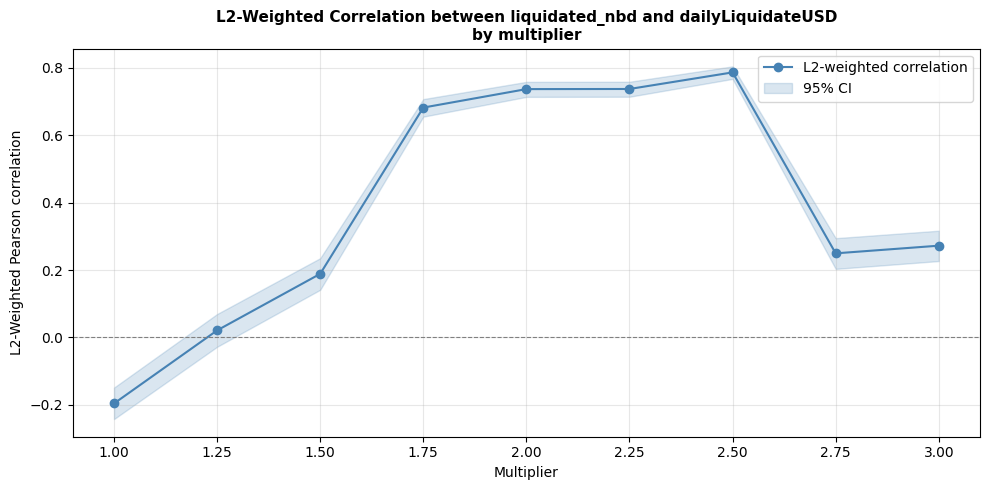

In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(corr_df_filtered['multiplier'], corr_df_filtered['corr'],
        color='steelblue', linewidth=1.5, marker='o', label='L2-weighted correlation')
ax.fill_between(corr_df_filtered['multiplier'], corr_df_filtered['ci_lo'], corr_df_filtered['ci_hi'],
                alpha=0.2, color='steelblue', label='95% CI')

ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('L2-Weighted Correlation between liquidated_nbd and dailyLiquidateUSD\nby multiplier',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Multiplier')
ax.set_ylabel('L2-Weighted Pearson correlation')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



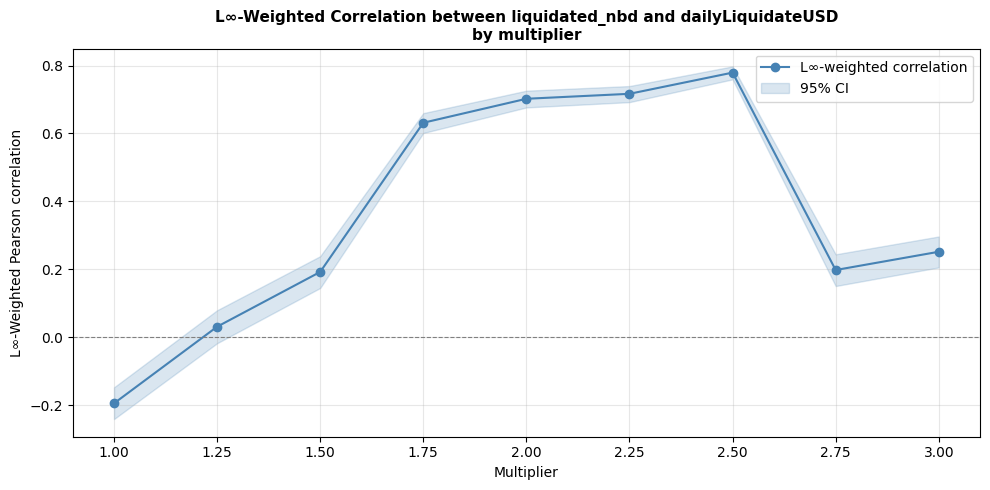

In [29]:
corr_data = []
for mult, df_m in df_combined.groupby('multiplier'):
    df_m = df_m[['liquidated_nbd', 'dailyLiquidateUSD']].dropna()
    n    = len(df_m)

    # Weight by L∞ norm (max of the two values)
    weights = np.maximum(df_m['liquidated_nbd'], df_m['dailyLiquidateUSD'])
    weights = weights / weights.sum()

    # Weighted means
    mean_x = np.average(df_m['liquidated_nbd'],    weights=weights)
    mean_y = np.average(df_m['dailyLiquidateUSD'], weights=weights)

    # Weighted correlation
    cov_xy = np.average((df_m['liquidated_nbd']    - mean_x) *
                        (df_m['dailyLiquidateUSD'] - mean_y), weights=weights)
    var_x  = np.average((df_m['liquidated_nbd']    - mean_x) ** 2, weights=weights)
    var_y  = np.average((df_m['dailyLiquidateUSD'] - mean_y) ** 2, weights=weights)
    r      = cov_xy / np.sqrt(var_x * var_y)

    # Fisher CI
    z     = np.arctanh(np.clip(r, -0.9999, 0.9999))
    se    = 1 / np.sqrt(n - 3)
    ci_lo = np.tanh(z - 1.96 * se)
    ci_hi = np.tanh(z + 1.96 * se)

    corr_data.append({'multiplier': mult, 'corr': r,
                      'ci_lo': ci_lo, 'ci_hi': ci_hi, 'n': n})

corr_df = pd.DataFrame(corr_data).sort_values('multiplier')
corr_df_filtered = corr_df[(corr_df['multiplier'] >= 1) & (corr_df['multiplier'] <= 3)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(corr_df_filtered['multiplier'], corr_df_filtered['corr'],
        color='steelblue', linewidth=1.5, marker='o', label='L∞-weighted correlation')
ax.fill_between(corr_df_filtered['multiplier'], corr_df_filtered['ci_lo'], corr_df_filtered['ci_hi'],
                alpha=0.2, color='steelblue', label='95% CI')
ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_title('L∞-Weighted Correlation between liquidated_nbd and dailyLiquidateUSD\nby multiplier',
             fontsize=11, fontweight='bold')
ax.set_xlabel('Multiplier')
ax.set_ylabel('L∞-Weighted Pearson correlation')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



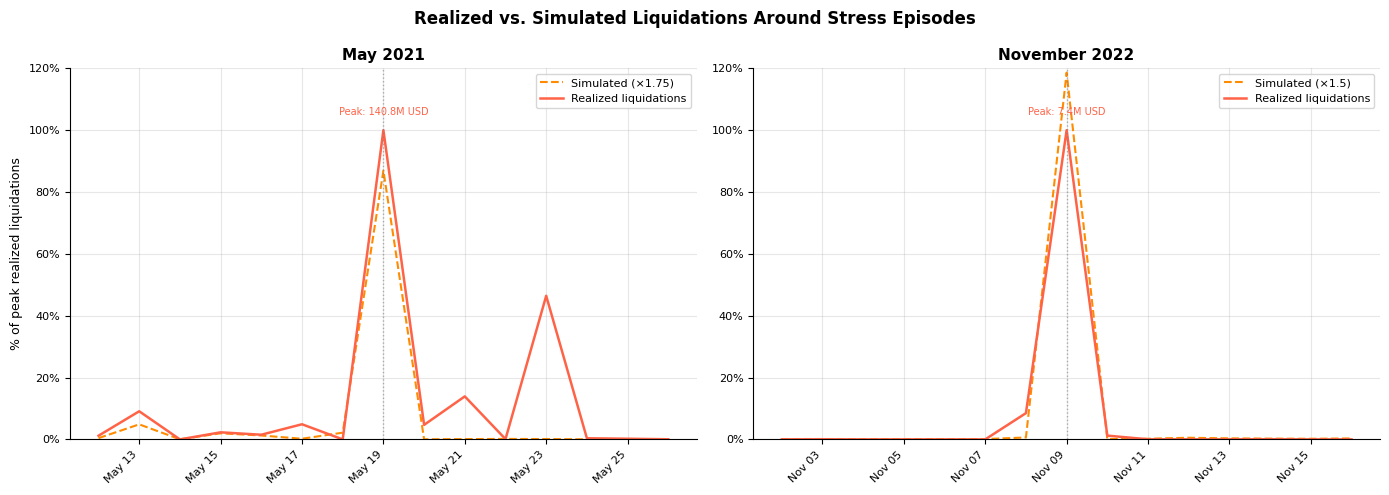

In [30]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

WINDOW_DAYS = 7
MULT_MAY    = 1.75
MULT_NOV    = 1.50
PEAK_MAY    = pd.Timestamp('2021-05-19')
PEAK_NOV    = pd.Timestamp('2022-11-09')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

panels_cfg = [
    (axes[0], MULT_MAY, PEAK_MAY, 'May 2021'),
    (axes[1], MULT_NOV, PEAK_NOV, 'November 2022'),
]

for ax, mult, peak, title in panels_cfg:
    df_mult  = df_combined[df_combined['multiplier'] == mult].sort_values('date')
    df_panel = df_mult[
        (df_mult['date'] >= peak - pd.Timedelta(days=WINDOW_DAYS)) &
        (df_mult['date'] <= peak + pd.Timedelta(days=WINDOW_DAYS))
    ].copy()

    # Normalize by peak value of realized liquidations
    peak_val = df_panel.loc[df_panel['date'] == peak, 'dailyLiquidateUSD'].values[0]
    df_panel['liq_pct']      = df_panel['liquidated_nbd']    / peak_val * 100
    df_panel['realized_pct'] = df_panel['dailyLiquidateUSD'] / peak_val * 100

    ax.plot(df_panel['date'], df_panel['liq_pct'],
            color='darkorange', lw=1.5, ls='--',
            label=f'Simulated (×{mult})')
    ax.plot(df_panel['date'], df_panel['realized_pct'],
            color='tomato', lw=1.8, label='Realized liquidations')

    ax.axvline(peak, color='gray', ls=':', lw=1, alpha=0.6)
    ax.set_ylim(0, 120)

    # Peak annotation
    ax.text(peak, 105,
            f'Peak: {peak_val/1e6:.1f}M USD',
            ha='center', fontsize=7, color='tomato')

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.0f}%')
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Y-label only on left panel — avoids fig.text positioning issues
axes[0].set_ylabel('% of peak realized liquidations', fontsize=9)
axes[1].set_ylabel('')

fig.suptitle('Realized vs. Simulated Liquidations Around Stress Episodes',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('liquidations_stress_episodes.pdf', bbox_inches='tight', dpi=150)
plt.show()

Top 30 real events (by liq_to_tvl):
      date  liq_to_tvl  dailyLiquidateUSD  totalValueLockedUSD
2020-03-12    0.057756       6.216734e+06         1.076387e+08
2020-11-26    0.034603       1.086339e+08         3.139474e+09
2020-03-08    0.014529       2.566735e+06         1.766680e+08
2022-06-14    0.012398       4.907927e+07         3.958546e+09
2021-02-23    0.010834       9.447844e+07         8.720247e+09
2022-06-18    0.009653       3.364712e+07         3.485691e+09
2021-05-19    0.009557       1.407947e+08         1.473217e+10
2022-06-13    0.008216       3.338049e+07         4.062675e+09
2020-03-09    0.006983       1.181571e+06         1.692158e+08
2022-06-15    0.006060       2.313459e+07         3.817676e+09
2020-03-11    0.005877       8.785697e+05         1.494861e+08
2021-05-23    0.005583       6.537126e+07         1.170802e+10
2020-03-16    0.005328       4.941080e+05         9.274473e+07
2022-05-12    0.005231       2.986167e+07         5.708310e+09
2022-01-21    0.005

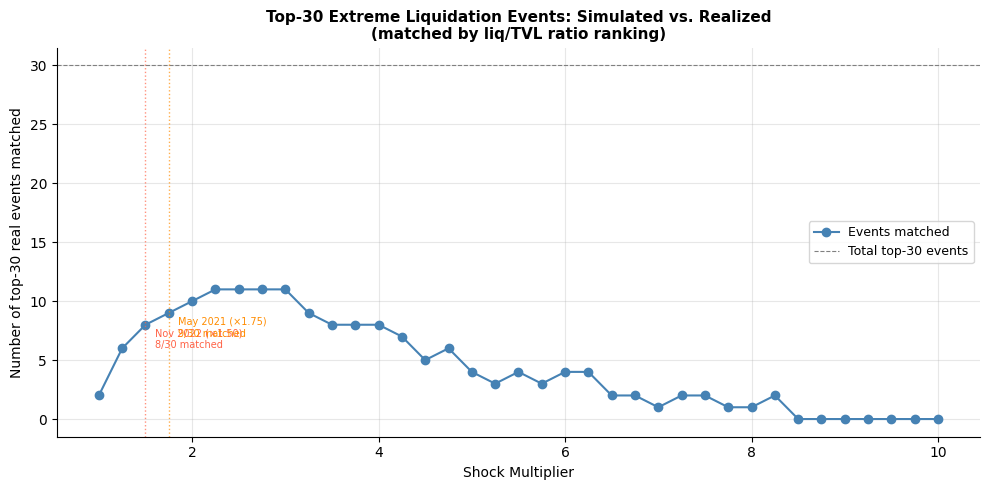


Multiplier = 1.5: matched dates
  2020-03-08  liq/TVL=0.0145  rank=3
  2020-03-11  liq/TVL=0.0059  rank=11
  2020-03-12  liq/TVL=0.0578  rank=1
  2020-05-10  liq/TVL=0.0033  rank=23
  2021-05-19  liq/TVL=0.0096  rank=7
  2022-01-21  liq/TVL=0.0052  rank=15
  2022-06-13  liq/TVL=0.0082  rank=8
  2022-11-09  liq/TVL=0.0029  rank=29

Multiplier = 1.75: matched dates
  2020-02-26  liq/TVL=0.0036  rank=19
  2020-03-08  liq/TVL=0.0145  rank=3
  2020-03-11  liq/TVL=0.0059  rank=11
  2020-03-12  liq/TVL=0.0578  rank=1
  2020-05-10  liq/TVL=0.0033  rank=23
  2021-05-19  liq/TVL=0.0096  rank=7
  2022-01-21  liq/TVL=0.0052  rank=15
  2022-06-13  liq/TVL=0.0082  rank=8
  2022-11-09  liq/TVL=0.0029  rank=29


In [31]:
# ══════════════════════════════════════════════════════════════════
# Top 30 extreme liquidation events — matching analysis
#
# For each multiplier, compute liq_to_tvl ratio for simulated
# data and check how many of the top 30 real events are matched.
#
# Requires:
#   dr_real   — real data with columns: date, dailyLiquidateUSD,
#               totalValueLockedUSD
#   df_combined — simulated data with columns: date, multiplier,
#                 liquidated_nbd
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Step 1: Top 30 real events by liq_to_tvl ─────────────────────
dr_real['date'] = pd.to_datetime(dr_real['date'])
dr_real['liq_to_tvl'] = (
    dr_real['dailyLiquidateUSD'] / dr_real['totalValueLockedUSD']
)

top30_real = (
    dr_real
    .nlargest(30, 'liq_to_tvl')[['date', 'liq_to_tvl',
                                   'dailyLiquidateUSD',
                                   'totalValueLockedUSD']]
    .reset_index(drop=True)
)
top30_dates = set(top30_real['date'])

print("Top 30 real events (by liq_to_tvl):")
print(top30_real.to_string(index=False))
print()

# ── Step 2: For each multiplier, compute simulated liq_to_tvl ────
# Aggregate simulated liquidations by date across all pools
df_sim_daily = (
    df_combined
    .groupby(['date', 'multiplier'])['liquidated_nbd']
    .sum()
    .reset_index()
)

# Merge with TVL from real data
df_sim_daily = df_sim_daily.merge(
    dr_real[['date', 'totalValueLockedUSD']],
    on='date', how='left'
)
df_sim_daily['liq_to_tvl_sim'] = (
    df_sim_daily['liquidated_nbd'] / df_sim_daily['totalValueLockedUSD']
)

# ── Step 3: For each multiplier, find top 30 simulated events ────
# and count overlap with real top 30
results = []
for mult, df_m in df_sim_daily.groupby('multiplier'):
    top30_sim = set(
        df_m.nlargest(30, 'liq_to_tvl_sim')['date']
    )
    matched    = top30_dates & top30_sim
    n_matched  = len(matched)
    results.append({
        'multiplier': mult,
        'n_matched':  n_matched,
        'pct_matched': n_matched / 30 * 100,
        'matched_dates': sorted(matched),
    })

results_df = pd.DataFrame(results).sort_values('multiplier')

print("Matching results by multiplier:")
print(results_df[['multiplier', 'n_matched', 'pct_matched']].to_string(index=False))
print()

# ── Step 4: Plot matching rate by multiplier ──────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(results_df['multiplier'], results_df['n_matched'],
        color='steelblue', lw=1.5, marker='o', label='Events matched')
ax.axhline(30, color='gray', ls='--', lw=0.8, label='Total top-30 events')

# Highlight benchmark multipliers
for mult, color, label in [(1.50, 'tomato', 'Nov 2022 (×1.50)'),
                            (1.75, 'darkorange', 'May 2021 (×1.75)')]:
    n = results_df.loc[results_df['multiplier'] == mult, 'n_matched']
    if len(n) > 0:
        ax.axvline(mult, color=color, ls=':', lw=1, alpha=0.7)
        ax.annotate(
            f'{label}\n{n.values[0]}/30 matched',
            xy=(mult, n.values[0]),
            xytext=(mult + 0.1, n.values[0] - 2),
            fontsize=7, color=color
        )

ax.set_xlabel('Shock Multiplier', fontsize=10)
ax.set_ylabel('Number of top-30 real events matched', fontsize=10)
ax.set_title(
    'Top-30 Extreme Liquidation Events: Simulated vs. Realized\n'
    '(matched by liq/TVL ratio ranking)',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('top30_matching.pdf', bbox_inches='tight', dpi=150)
plt.show()

# ── Step 5: Print matched dates for benchmark multipliers ─────────
for mult in [1.50, 1.75]:
    row = [r for r in results if r['multiplier'] == mult]
    if row:
        print(f"\nMultiplier = {mult}: matched dates")
        for d in row[0]['matched_dates']:
            real_row = top30_real[top30_real['date'] == d]
            if len(real_row) > 0:
                rank = top30_real.index[top30_real['date'] == d].tolist()
                print(f"  {d.date()}  "
                      f"liq/TVL={real_row['liq_to_tvl'].values[0]:.4f}  "
                      f"rank={rank[0]+1 if rank else '?'}")

In [32]:
for PCTILE_THRESHOLD in [90, 95, 99]:
    print(f"\n=== Percentile threshold: {PCTILE_THRESHOLD} ===")
    
    # Real extreme days: top (100-PCTILE_THRESHOLD)% of real distribution
    real_threshold = dr_real['liq_to_tvl'].quantile(PCTILE_THRESHOLD/100)
    real_extreme_dates = set(
        dr_real[dr_real['liq_to_tvl'] >= real_threshold]['date']
    )
    print(f"  Real: {len(real_extreme_dates)} extreme days "
          f"(threshold={real_threshold:.6f})")
    
    for mult in [1.25, 1.50, 1.75, 2.0, 2.5]:
        df_m = df_sim_daily[df_sim_daily['multiplier'] == mult].copy()
        sim_threshold = df_m['liq_to_tvl_sim'].quantile(PCTILE_THRESHOLD/100)
        sim_extreme_dates = set(
            df_m[df_m['liq_to_tvl_sim'] >= sim_threshold]['date']
        )
        
        # Intersection
        matched = real_extreme_dates & sim_extreme_dates
        n_real  = len(real_extreme_dates)
        
        print(f"  mult={mult}  "
              f"sim_extreme={len(sim_extreme_dates)}  "
              f"matched={len(matched)}/{n_real} "
              f"({len(matched)/n_real*100:.0f}%)")


=== Percentile threshold: 90 ===
  Real: 163 extreme days (threshold=0.000129)
  mult=1.25  sim_extreme=163  matched=21/163 (13%)
  mult=1.5  sim_extreme=163  matched=36/163 (22%)
  mult=1.75  sim_extreme=163  matched=47/163 (29%)
  mult=2.0  sim_extreme=163  matched=62/163 (38%)
  mult=2.5  sim_extreme=163  matched=69/163 (42%)

=== Percentile threshold: 95 ===
  Real: 82 extreme days (threshold=0.000450)
  mult=1.25  sim_extreme=82  matched=10/82 (12%)
  mult=1.5  sim_extreme=82  matched=19/82 (23%)
  mult=1.75  sim_extreme=82  matched=24/82 (29%)
  mult=2.0  sim_extreme=82  matched=30/82 (37%)
  mult=2.5  sim_extreme=82  matched=29/82 (35%)

=== Percentile threshold: 99 ===
  Real: 17 extreme days (threshold=0.004048)
  mult=1.25  sim_extreme=17  matched=5/17 (29%)
  mult=1.5  sim_extreme=17  matched=6/17 (35%)
  mult=1.75  sim_extreme=17  matched=6/17 (35%)
  mult=2.0  sim_extreme=17  matched=5/17 (29%)
  mult=2.5  sim_extreme=17  matched=4/17 (24%)


Top 1%  mult=1.25  real=17  matched=5  hit_rate=29%
Top 1%  mult=1.5  real=17  matched=6  hit_rate=35%
Top 1%  mult=1.75  real=17  matched=6  hit_rate=35%
Top 1%  mult=2.0  real=17  matched=5  hit_rate=29%
Top 1%  mult=2.5  real=17  matched=4  hit_rate=24%
Top 2%  mult=1.25  real=33  matched=6  hit_rate=18%
Top 2%  mult=1.5  real=33  matched=8  hit_rate=24%
Top 2%  mult=1.75  real=33  matched=9  hit_rate=27%
Top 2%  mult=2.0  real=33  matched=11  hit_rate=33%
Top 2%  mult=2.5  real=33  matched=11  hit_rate=33%
Top 5%  mult=1.25  real=82  matched=10  hit_rate=12%
Top 5%  mult=1.5  real=82  matched=19  hit_rate=23%
Top 5%  mult=1.75  real=82  matched=24  hit_rate=29%
Top 5%  mult=2.0  real=82  matched=30  hit_rate=37%
Top 5%  mult=2.5  real=82  matched=29  hit_rate=35%
Top 10%  mult=1.25  real=163  matched=21  hit_rate=13%
Top 10%  mult=1.5  real=163  matched=36  hit_rate=22%
Top 10%  mult=1.75  real=163  matched=47  hit_rate=29%
Top 10%  mult=2.0  real=163  matched=62  hit_rate=38%
Top 

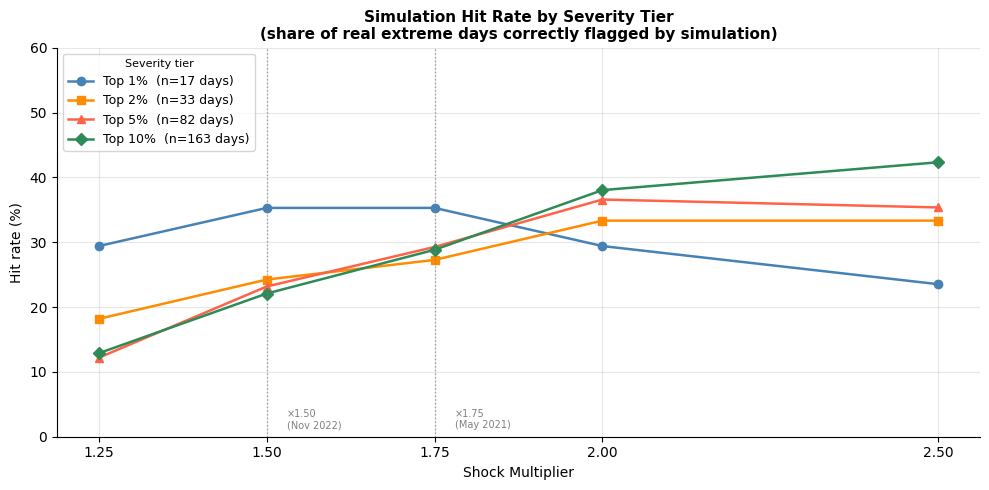

Saved: hit_rate_by_tier.pdf

Summary table:
tier  Top 1%  Top 10%  Top 2%  Top 5%
mult                                 
1.25    29.0     13.0    18.0    12.0
1.50    35.0     22.0    24.0    23.0
1.75    35.0     29.0    27.0    29.0
2.00    29.0     38.0    33.0    37.0
2.50    24.0     42.0    33.0    35.0


In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

MULTIPLIERS = [1.25, 1.50, 1.75, 2.0, 2.5]
TIERS       = [1, 2, 5, 10]   # top X% of real distribution
COLORS      = ['steelblue', 'darkorange', 'tomato', 'seagreen', 'purple']
MARKERS     = ['o', 's', '^', 'D', 'v']

# ── Build hit rate table ──────────────────────────────────────────
results = []

for pctile in TIERS:
    threshold_real = 100 - pctile   # e.g. top 1% = quantile 0.99
    real_threshold = dr_real['liq_to_tvl'].quantile(threshold_real / 100)
    real_extreme   = set(
        dr_real[dr_real['liq_to_tvl'] >= real_threshold]['date']
    )
    n_real = len(real_extreme)

    for mult in MULTIPLIERS:
        df_m          = df_sim_daily[df_sim_daily['multiplier'] == mult].copy()
        sim_threshold = df_m['liq_to_tvl_sim'].quantile(threshold_real / 100)
        sim_extreme   = set(
            df_m[df_m['liq_to_tvl_sim'] >= sim_threshold]['date']
        )
        matched  = real_extreme & sim_extreme
        hit_rate = len(matched) / n_real * 100

        results.append({
            'tier':      f'Top {pctile}%',
            'pctile':    pctile,
            'mult':      mult,
            'n_real':    n_real,
            'n_matched': len(matched),
            'hit_rate':  hit_rate,
        })
        print(f"Top {pctile}%  mult={mult}  "
              f"real={n_real}  matched={len(matched)}  "
              f"hit_rate={hit_rate:.0f}%")

df_results = pd.DataFrame(results)

# ── Plot: hit rate by multiplier, one line per severity tier ──────
fig, ax = plt.subplots(figsize=(10, 5))

for i, (pctile, color, marker) in enumerate(
        zip(TIERS, COLORS, MARKERS)):
    sub = df_results[df_results['pctile'] == pctile]
    n   = sub['n_real'].iloc[0]
    ax.plot(sub['mult'], sub['hit_rate'],
            color=color, lw=1.8, marker=marker, ms=6,
            label=f'Top {pctile}%  (n={n} days)')

# Benchmark multiplier lines
for mult, label in [(1.50, '×1.50\n(Nov 2022)'),
                    (1.75, '×1.75\n(May 2021)')]:
    ax.axvline(mult, color='gray', ls=':', lw=1, alpha=0.7)
    ax.text(mult + 0.03, 1, label, fontsize=7,
            color='gray', va='bottom')

ax.set_xlabel('Shock Multiplier', fontsize=10)
ax.set_ylabel('Hit rate (%)', fontsize=10)
ax.set_title(
    'Simulation Hit Rate by Severity Tier\n'
    '(share of real extreme days correctly flagged by simulation)',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=9, title='Severity tier', title_fontsize=8,
          loc='upper left')
ax.set_xticks(MULTIPLIERS)
ax.set_ylim(0, 60)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('hit_rate_by_tier.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: hit_rate_by_tier.pdf')

# ── Summary table ─────────────────────────────────────────────────
print("\nSummary table:")
pivot = df_results.pivot(index='mult', columns='tier', values='hit_rate')
print(pivot.round(0).to_string())

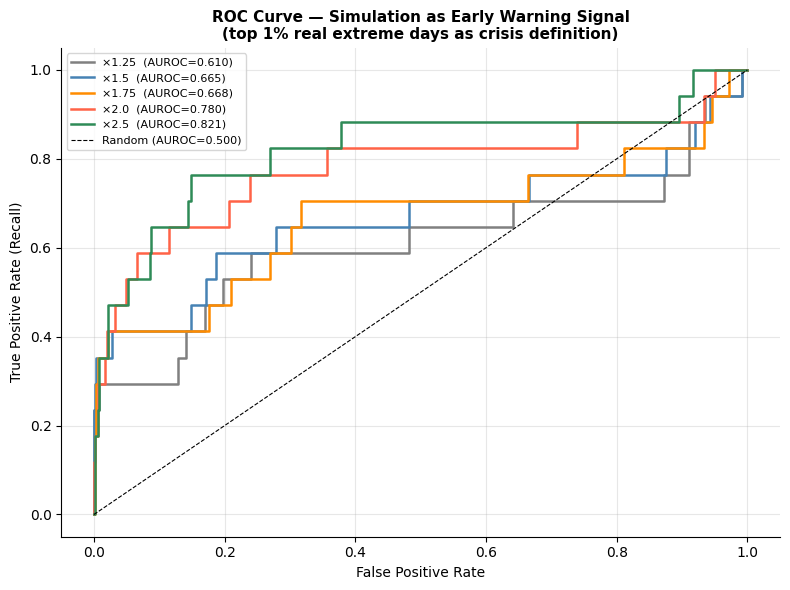

In [34]:
from sklearn.metrics import roc_auc_score, roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

for mult, color in [(1.25,'gray'), (1.50,'steelblue'),
                    (1.75,'darkorange'), (2.0,'tomato'),
                    (2.5,'seagreen')]:
    df_m   = df_sim_daily[df_sim_daily['multiplier'] == mult].copy()
    merged = dr_real.merge(
        df_m[['date','liq_to_tvl_sim']], on='date', how='left'
    ).fillna(0)

    # Binary: is this day in top 1% real?
    real_threshold = merged['liq_to_tvl'].quantile(0.99)
    y_true  = (merged['liq_to_tvl'] >= real_threshold).astype(int)
    y_score = merged['liq_to_tvl_sim']

    auroc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)

    ax.plot(fpr, tpr, color=color, lw=1.8,
            label=f'×{mult}  (AUROC={auroc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random (AUROC=0.500)')
ax.set_xlabel('False Positive Rate', fontsize=10)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=10)
ax.set_title('ROC Curve — Simulation as Early Warning Signal\n'
             '(top 1% real extreme days as crisis definition)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('roc_curve.pdf', bbox_inches='tight', dpi=150)
plt.show()

In [35]:
from sklearn.metrics import roc_curve

df_m   = df_sim_daily[df_sim_daily['multiplier'] == 1.50].copy()
merged = dr_real.merge(df_m[['date','liq_to_tvl_sim']], 
                       on='date', how='left').fillna(0)
real_threshold = merged['liq_to_tvl'].quantile(0.99)
y_true  = (merged['liq_to_tvl'] >= real_threshold).astype(int)
y_score = merged['liq_to_tvl_sim']

fpr, tpr, thresholds = roc_curve(y_true, y_score)
print(f"Max threshold: {thresholds.max():.6f}")
print(f"Min threshold: {thresholds.min():.6f}")
print(f"Number of threshold steps: {len(thresholds)}")
print(f"\nThresholds where TPR changes:")
tpr_changes = thresholds[np.diff(tpr, prepend=0) > 0]
print(tpr_changes)

Max threshold: inf
Min threshold: 0.000000
Number of threshold steps: 32

Thresholds where TPR changes:
[4.47717187e-02 5.22131194e-03 5.01154973e-03 1.72433168e-03
 5.91222025e-04 9.95073168e-05 2.34053532e-05 2.02868136e-05
 1.92692999e-05 1.14540578e-05 5.98310781e-06 2.36235444e-06
 8.03479212e-07 2.29574675e-07 1.00494867e-07 7.32675697e-09]


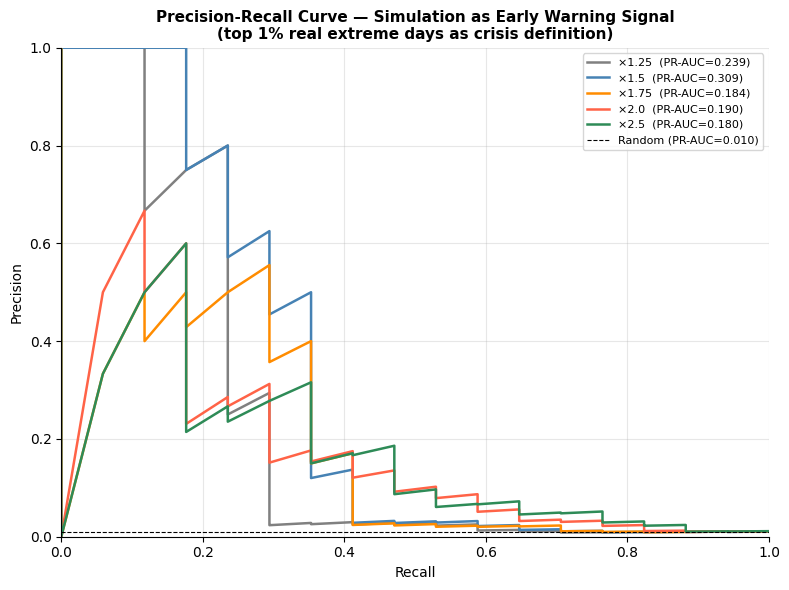

Base rate (random classifier): 0.010
n positive (real extreme days): 17
n total: 1628


In [36]:
from sklearn.metrics import precision_recall_curve, auc, average_precision_score
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

for mult, color in [(1.25,'gray'), (1.50,'steelblue'),
                    (1.75,'darkorange'), (2.0,'tomato'),
                    (2.5,'seagreen')]:
    df_m   = df_sim_daily[df_sim_daily['multiplier'] == mult].copy()
    merged = dr_real.merge(
        df_m[['date','liq_to_tvl_sim']], on='date', how='left'
    ).fillna(0)

    real_threshold = merged['liq_to_tvl'].quantile(0.99)
    y_true  = (merged['liq_to_tvl'] >= real_threshold).astype(int)
    y_score = merged['liq_to_tvl_sim']

    precision, recall, _ = precision_recall_curve(y_true, y_score)
    pr_auc = average_precision_score(y_true, y_score)

    ax.plot(recall, precision, color=color, lw=1.8,
            label=f'×{mult}  (PR-AUC={pr_auc:.3f})')

# Random baseline = base rate of positive class
base_rate = y_true.mean()
ax.axhline(base_rate, color='black', ls='--', lw=0.8,
           label=f'Random (PR-AUC={base_rate:.3f})')

ax.set_xlabel('Recall', fontsize=10)
ax.set_ylabel('Precision', fontsize=10)
ax.set_title(
    'Precision-Recall Curve — Simulation as Early Warning Signal\n'
    '(top 1% real extreme days as crisis definition)',
    fontsize=11, fontweight='bold'
)
ax.legend(fontsize=8)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('pr_curve.pdf', bbox_inches='tight', dpi=150)
plt.show()

# Print summary
print(f"Base rate (random classifier): {base_rate:.3f}")
print(f"n positive (real extreme days): {y_true.sum()}")
print(f"n total: {len(y_true)}")

In [37]:
print(recall)

[1. 1. 1. ... 0. 0. 0.]


In [38]:
# Top 5 real extreme days to pick a third episode
print("Top 10 real extreme days:")
print(
    dr_real.nlargest(10, 'liq_to_tvl')[
        ['date', 'liq_to_tvl', 'dailyLiquidateUSD', 
         'totalValueLockedUSD']
    ].to_string(index=False)
)

Top 10 real extreme days:
      date  liq_to_tvl  dailyLiquidateUSD  totalValueLockedUSD
2020-03-12    0.057756       6.216734e+06         1.076387e+08
2020-11-26    0.034603       1.086339e+08         3.139474e+09
2020-03-08    0.014529       2.566735e+06         1.766680e+08
2022-06-14    0.012398       4.907927e+07         3.958546e+09
2021-02-23    0.010834       9.447844e+07         8.720247e+09
2022-06-18    0.009653       3.364712e+07         3.485691e+09
2021-05-19    0.009557       1.407947e+08         1.473217e+10
2022-06-13    0.008216       3.338049e+07         4.062675e+09
2020-03-09    0.006983       1.181571e+06         1.692158e+08
2022-06-15    0.006060       2.313459e+07         3.817676e+09


In [39]:
PEAKS = {
    'Mar 12, 2020 (COVID)':     pd.Timestamp('2020-03-12'),
    'Nov 26, 2020':              pd.Timestamp('2020-11-26'),
    'Jun 14, 2022 (Terra aft.)': pd.Timestamp('2022-06-14'),
    'May 19, 2021 (BTC crash)':  pd.Timestamp('2021-05-19'),
    'Nov 9, 2022 (FTX)':         pd.Timestamp('2022-11-09'),
}

for mult in [1.50, 1.75, 2.0]:
    print(f"\n=== Multiplier = {mult} ===")
    df_m = df_sim_daily[df_sim_daily['multiplier'] == mult].sort_values('date')
    
    for label, peak in PEAKS.items():
        row      = df_m[df_m['date'] == peak]
        real_row = dr_real[dr_real['date'] == peak]
        
        if len(row) > 0 and len(real_row) > 0:
            sim_val    = row['liq_to_tvl_sim'].values[0]
            real_val   = real_row['liq_to_tvl'].values[0]
            sim_pctile = (df_m['liq_to_tvl_sim'] <= sim_val).mean() * 100
            pct_of_real = sim_val / real_val * 100
            
            print(f"  {label:<30}  "
                  f"real={real_val:.5f}  "
                  f"sim={sim_val:.5f}  "
                  f"sim_pctile={sim_pctile:.1f}  "
                  f"sim/real={pct_of_real:.1f}%")
        else:
            print(f"  {label:<30}  *** no data")


=== Multiplier = 1.5 ===
  Mar 12, 2020 (COVID)            real=0.05776  sim=0.04477  sim_pctile=100.0  sim/real=77.5%
  Nov 26, 2020                    real=0.03460  sim=0.00000  sim_pctile=12.6  sim/real=0.0%
  Jun 14, 2022 (Terra aft.)       real=0.01240  sim=0.00001  sim_pctile=71.8  sim/real=0.1%
  May 19, 2021 (BTC crash)        real=0.00956  sim=0.00172  sim_pctile=99.6  sim/real=18.0%
  Nov 9, 2022 (FTX)               real=0.00291  sim=0.00345  sim_pctile=99.6  sim/real=118.6%

=== Multiplier = 1.75 ===
  Mar 12, 2020 (COVID)            real=0.05776  sim=0.00462  sim_pctile=99.6  sim/real=8.0%
  Nov 26, 2020                    real=0.03460  sim=0.00000  sim_pctile=18.9  sim/real=0.0%
  Jun 14, 2022 (Terra aft.)       real=0.01240  sim=0.00001  sim_pctile=67.9  sim/real=0.1%
  May 19, 2021 (BTC crash)        real=0.00956  sim=0.00831  sim_pctile=99.8  sim/real=86.9%
  Nov 9, 2022 (FTX)               real=0.00291  sim=0.01333  sim_pctile=100.0  sim/real=458.7%

=== Multiplier = 

In [40]:
for peak, label in [
    (pd.Timestamp('2021-02-23'), 'Feb 23, 2021'),
    (pd.Timestamp('2020-03-08'), 'Mar 8, 2020'),
]:
    print(f"\n{label}")
    for mult in [1.50, 1.75, 2.0]:
        df_m     = df_sim_daily[df_sim_daily['multiplier'] == mult].sort_values('date')
        row      = df_m[df_m['date'] == peak]
        real_row = dr_real[dr_real['date'] == peak]
        if len(row) > 0 and len(real_row) > 0:
            sim_val    = row['liq_to_tvl_sim'].values[0]
            real_val   = real_row['liq_to_tvl'].values[0]
            sim_pctile = (df_m['liq_to_tvl_sim'] <= sim_val).mean() * 100
            print(f"  mult={mult}  sim/real={sim_val/real_val*100:.1f}%  "
                  f"sim_pctile={sim_pctile:.1f}")


Feb 23, 2021
  mult=1.5  sim/real=0.0%  sim_pctile=33.4
  mult=1.75  sim/real=0.0%  sim_pctile=33.5
  mult=2.0  sim/real=1.3%  sim_pctile=94.7

Mar 8, 2020
  mult=1.5  sim/real=35.9%  sim_pctile=99.9
  mult=1.75  sim/real=70.1%  sim_pctile=99.9
  mult=2.0  sim/real=56.4%  sim_pctile=99.8


In [41]:
print("Top 10 real extreme days by liq/TVL ratio:")
print(
    dr_real.nlargest(10, 'liq_to_tvl')[
        ['date', 'liq_to_tvl', 'dailyLiquidateUSD', 
         'totalValueLockedUSD']
    ].assign(
        TVL_B=lambda x: x['totalValueLockedUSD']/1e9,
        liq_M=lambda x: x['dailyLiquidateUSD']/1e6
    )[['date','liq_to_tvl','liq_M','TVL_B']]
    .rename(columns={
        'liq_to_tvl': 'liq/TVL',
        'liq_M':      'Liquidations ($M)',
        'TVL_B':      'TVL ($B)'
    })
    .to_string(index=False)
)

print("\n\nTop 10 real extreme days by absolute liquidation volume ($):")
print(
    dr_real.nlargest(10, 'dailyLiquidateUSD')[
        ['date', 'liq_to_tvl', 'dailyLiquidateUSD',
         'totalValueLockedUSD']
    ].assign(
        TVL_B=lambda x: x['totalValueLockedUSD']/1e9,
        liq_M=lambda x: x['dailyLiquidateUSD']/1e6
    )[['date','liq_to_tvl','liq_M','TVL_B']]
    .rename(columns={
        'liq_to_tvl': 'liq/TVL',
        'liq_M':      'Liquidations ($M)',
        'TVL_B':      'TVL ($B)'
    })
    .to_string(index=False)
)

Top 10 real extreme days by liq/TVL ratio:
      date  liq/TVL  Liquidations ($M)  TVL ($B)
2020-03-12 0.057756           6.216734  0.107639
2020-11-26 0.034603         108.633938  3.139474
2020-03-08 0.014529           2.566735  0.176668
2022-06-14 0.012398          49.079273  3.958546
2021-02-23 0.010834          94.478440  8.720247
2022-06-18 0.009653          33.647123  3.485691
2021-05-19 0.009557         140.794745 14.732173
2022-06-13 0.008216          33.380485  4.062675
2020-03-09 0.006983           1.181571  0.169216
2022-06-15 0.006060          23.134594  3.817676


Top 10 real extreme days by absolute liquidation volume ($):
      date  liq/TVL  Liquidations ($M)  TVL ($B)
2021-05-19 0.009557         140.794745 14.732173
2020-11-26 0.034603         108.633938  3.139474
2021-02-23 0.010834          94.478440  8.720247
2021-05-23 0.005583          65.371261 11.708022
2022-01-21 0.005183          60.132835 11.602173
2022-06-14 0.012398          49.079273  3.958546
2022-06-18 0

In [42]:
top10_relative = dr_real.nlargest(10, 'liq_to_tvl')

print("Top 10 relative crashes — simulation matching:")
print(f"{'Date':<15} {'liq/TVL':>8} {'Liq($M)':>9} {'TVL($B)':>8} ", end='')
for mult in [1.50, 1.75, 2.0]:
    print(f"{'sim/real('+str(mult)+')':>14}", end='')
print(f"  {'sim_pctile(1.75)':>16}  {'matched?':>8}")
print("-"*110)

for _, row in top10_relative.iterrows():
    peak     = row['date']
    real_val = row['liq_to_tvl']
    liq_M    = row['dailyLiquidateUSD']/1e6
    tvl_B    = row['totalValueLockedUSD']/1e9
    
    print(f"{str(peak.date()):<15} {real_val:>8.4f} {liq_M:>9.1f} {tvl_B:>8.2f} ", end='')
    
    pctile_175 = None
    for mult in [1.50, 1.75, 2.0]:
        df_m    = df_sim_daily[df_sim_daily['multiplier'] == mult].sort_values('date')
        sim_row = df_m[df_m['date'] == peak]
        if len(sim_row) > 0:
            sim_val    = sim_row['liq_to_tvl_sim'].values[0]
            sim_pctile = (df_m['liq_to_tvl_sim'] <= sim_val).mean() * 100
            pct_real   = sim_val / real_val * 100
            if mult == 1.75:
                pctile_175 = sim_pctile
            print(f"{pct_real:>13.1f}%", end='')
        else:
            print(f"{'N/A':>14}", end='')
    
    matched = '✓' if pctile_175 and pctile_175 >= 95 else '✗'
    print(f"  {pctile_175:>16.1f}  {matched:>8}")

Top 10 relative crashes — simulation matching:
Date             liq/TVL   Liq($M)  TVL($B)  sim/real(1.5)sim/real(1.75) sim/real(2.0)  sim_pctile(1.75)  matched?
--------------------------------------------------------------------------------------------------------------
2020-03-12        0.0578       6.2     0.11          77.5%          8.0%          1.2%              99.6         ✓
2020-11-26        0.0346     108.6     3.14           0.0%          0.0%          0.3%              18.9         ✗
2020-03-08        0.0145       2.6     0.18          35.9%         70.1%         56.4%              99.9         ✓
2022-06-14        0.0124      49.1     3.96           0.1%          0.1%          0.1%              67.9         ✗
2021-02-23        0.0108      94.5     8.72           0.0%          0.0%          1.3%              33.5         ✗
2022-06-18        0.0097      33.6     3.49           0.2%          0.2%          3.3%              72.9         ✗
2021-05-19        0.0096     140.8   

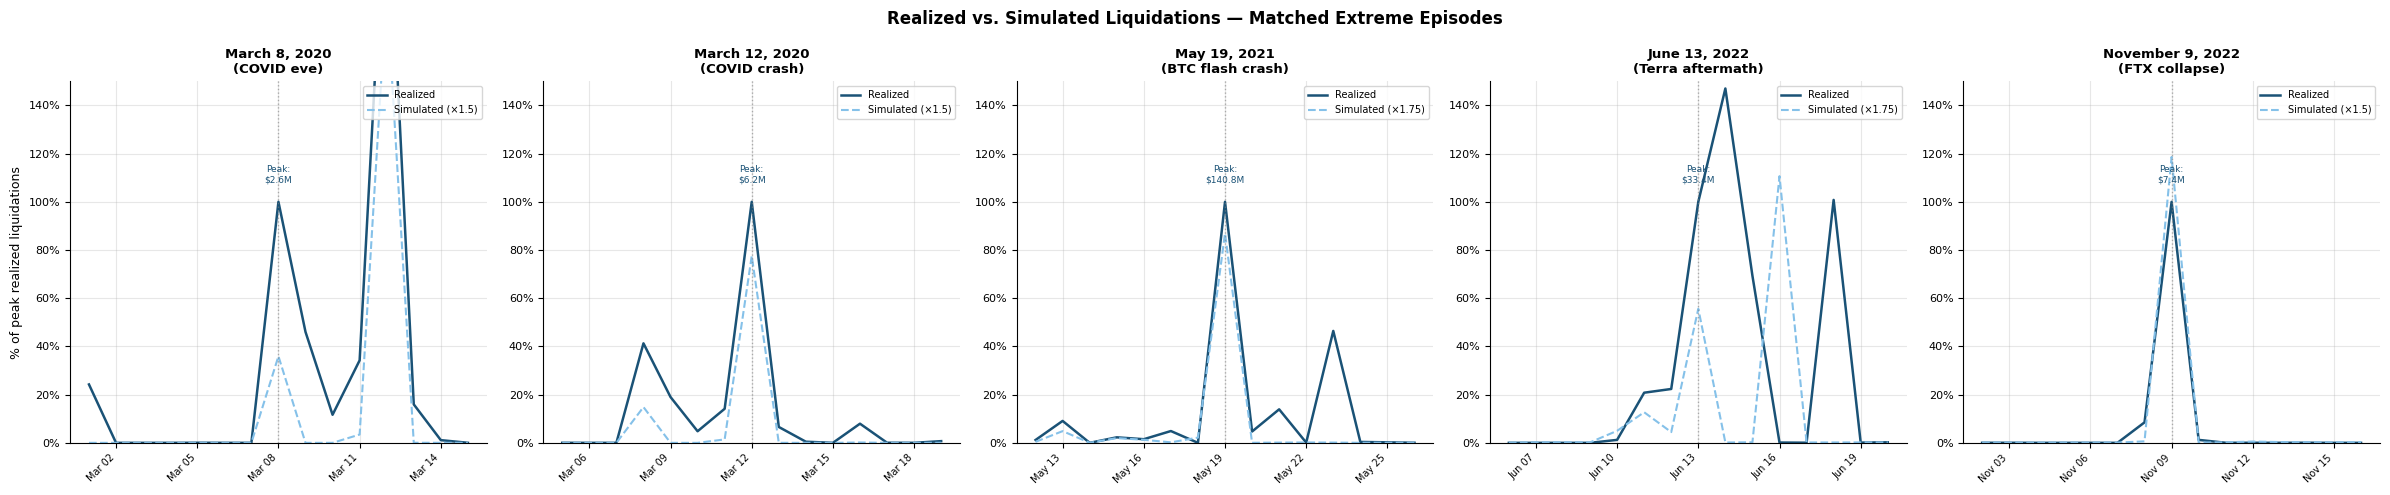

Saved: liquidations_5episodes.pdf


In [43]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ── Config ────────────────────────────────────────────────────────
WINDOW_DAYS = 7

episodes = [
    (pd.Timestamp('2020-03-08'), 1.50, 'March 8, 2020\n(COVID eve)'),
    (pd.Timestamp('2020-03-12'), 1.50, 'March 12, 2020\n(COVID crash)'),
    (pd.Timestamp('2021-05-19'), 1.75, 'May 19, 2021\n(BTC flash crash)'),
    (pd.Timestamp('2022-06-13'), 1.75, 'June 13, 2022\n(Terra aftermath)'),
    (pd.Timestamp('2022-11-09'), 1.50, 'November 9, 2022\n(FTX collapse)'),
]

# ── Colors ────────────────────────────────────────────────────────
COLOR_REAL = '#1a5276'    # dark blue — realized
COLOR_SIM  = '#85c1e9'    # light blue — simulated

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

for ax, (peak, mult, title) in zip(axes, episodes):

    # Filter simulated data
    df_m = df_sim_daily[
        df_sim_daily['multiplier'] == mult
    ].sort_values('date')
    df_panel = df_m[
        (df_m['date'] >= peak - pd.Timedelta(days=WINDOW_DAYS)) &
        (df_m['date'] <= peak + pd.Timedelta(days=WINDOW_DAYS))
    ].copy()

    # Filter real data
    df_real_panel = dr_real[
        (dr_real['date'] >= peak - pd.Timedelta(days=WINDOW_DAYS)) &
        (dr_real['date'] <= peak + pd.Timedelta(days=WINDOW_DAYS))
    ].copy()

    # Normalize by peak realized value
    peak_val = dr_real.loc[
        dr_real['date'] == peak, 'dailyLiquidateUSD'
    ].values[0]

    df_panel['liq_pct']       = df_panel['liquidated_nbd']     / peak_val * 100
    df_real_panel['real_pct'] = df_real_panel['dailyLiquidateUSD'] / peak_val * 100

    # Plot
    ax.plot(df_real_panel['date'], df_real_panel['real_pct'],
            color=COLOR_REAL, lw=1.8, label='Realized')
    ax.plot(df_panel['date'], df_panel['liq_pct'],
            color=COLOR_SIM, lw=1.5, ls='--',
            label=f'Simulated (×{mult})')

    ax.axvline(peak, color='gray', ls=':', lw=1, alpha=0.6)
    ax.set_ylim(0, 150)

    # Peak annotation
    ax.text(peak, 108,
            f'Peak:\n${peak_val/1e6:.1f}M',
            ha='center', fontsize=6.5, color=COLOR_REAL)

    # Formatting
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(),
             rotation=45, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.0f}%')
    )
    ax.tick_params(axis='y', labelsize=8)
    ax.set_title(title, fontsize=9.5, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Y-label on leftmost panel only
axes[0].set_ylabel('% of peak realized liquidations', fontsize=9)

fig.suptitle(
    'Realized vs. Simulated Liquidations — Matched Extreme Episodes',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig('liquidations_5episodes.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: liquidations_5episodes.pdf')

In [44]:
WINDOWS = [0, 1, 2, 3]  # days around the peak to check

top10_dates = dr_real.nlargest(10, 'liq_to_tvl')['date'].tolist()

print("Matching within window of N days around peak (mult=1.75, pctile>=95):")
print(f"{'Date':<15} {'liq/TVL':>8} ", end='')
for w in WINDOWS:
    print(f"{'±'+str(w)+'d':>8}", end='')
print()
print("-" * 60)

df_m = df_sim_daily[df_sim_daily['multiplier'] == 1.75].sort_values('date')
sim_threshold_95 = df_m['liq_to_tvl_sim'].quantile(0.95)

for peak in top10_dates:
    real_val = dr_real.loc[dr_real['date'] == peak, 'liq_to_tvl'].values[0]
    print(f"{str(peak.date()):<15} {real_val:>8.4f} ", end='')
    
    for w in WINDOWS:
        # Check if any day within ±w days exceeds the 95th percentile
        window_dates = [peak + pd.Timedelta(days=d) 
                       for d in range(-w, w+1)]
        sim_window = df_m[df_m['date'].isin(window_dates)]
        matched = (sim_window['liq_to_tvl_sim'] >= sim_threshold_95).any()
        print(f"{'✓' if matched else '✗':>8}", end='')
    print()

print("\nTotal matched:")
for w in WINDOWS:
    n = 0
    for peak in top10_dates:
        window_dates = [peak + pd.Timedelta(days=d) 
                       for d in range(-w, w+1)]
        sim_window = df_m[df_m['date'].isin(window_dates)]
        if (sim_window['liq_to_tvl_sim'] >= sim_threshold_95).any():
            n += 1
    print(f"  ±{w} days: {n}/10")

Matching within window of N days around peak (mult=1.75, pctile>=95):
Date             liq/TVL      ±0d     ±1d     ±2d     ±3d
------------------------------------------------------------
2020-03-12        0.0578        ✓       ✓       ✓       ✓
2020-11-26        0.0346        ✗       ✗       ✗       ✗
2020-03-08        0.0145        ✓       ✓       ✓       ✓
2022-06-14        0.0124        ✗       ✓       ✓       ✓
2021-02-23        0.0108        ✗       ✗       ✗       ✗
2022-06-18        0.0097        ✗       ✗       ✓       ✓
2021-05-19        0.0096        ✓       ✓       ✓       ✓
2022-06-13        0.0082        ✓       ✓       ✓       ✓
2020-03-09        0.0070        ✗       ✓       ✓       ✓
2022-06-15        0.0061        ✗       ✓       ✓       ✓

Total matched:
  ±0 days: 4/10
  ±1 days: 7/10
  ±2 days: 8/10
  ±3 days: 8/10


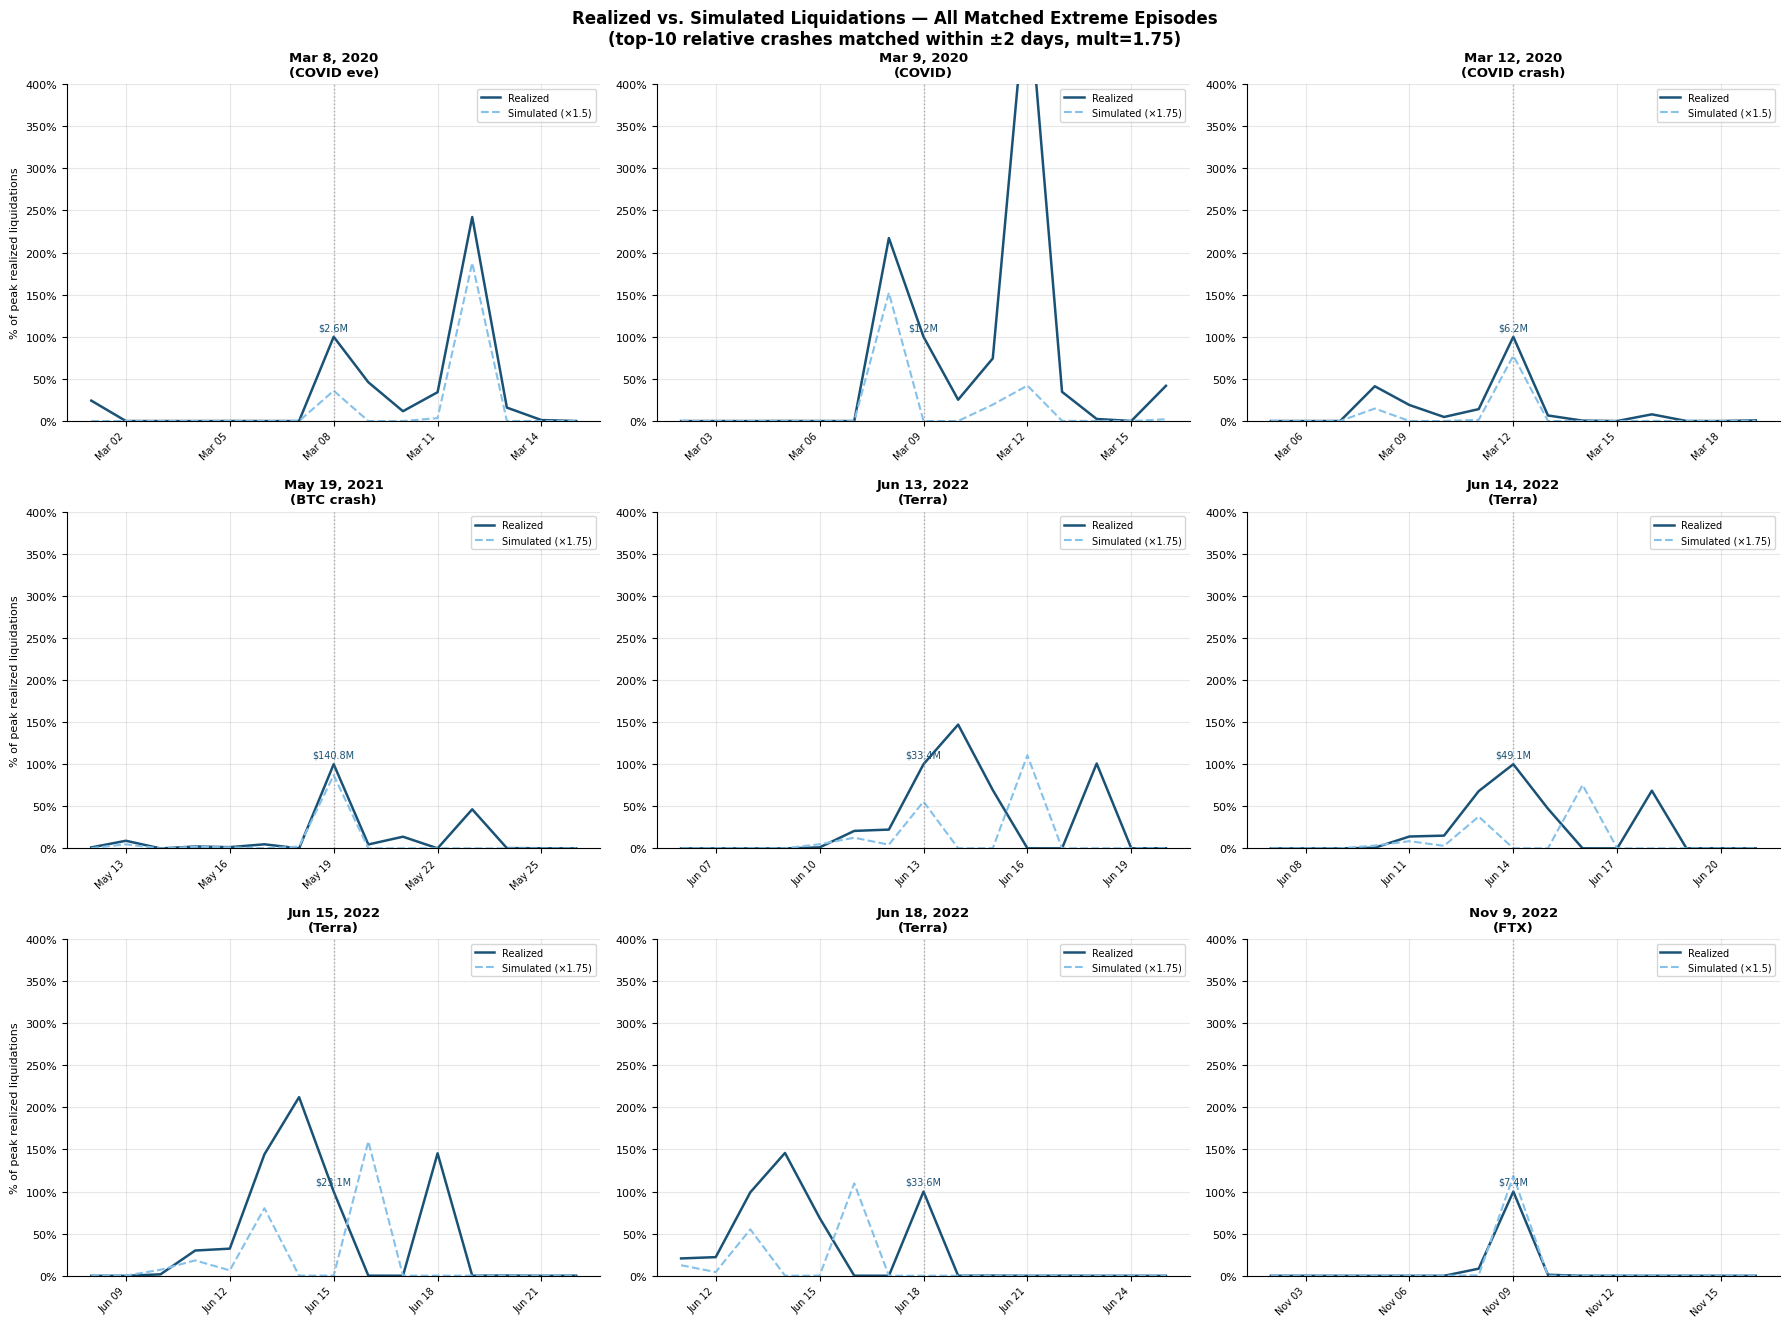

Saved: liquidations_all_episodes.pdf


In [45]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ══════════════════════════════════════════════════════════════════
# All matched extreme episodes figure
# Shows all top-10 relative crashes that are matched within ±2 days
# ══════════════════════════════════════════════════════════════════

WINDOW_DAYS = 7   # display window around peak
COLOR_REAL  = '#1a5276'   # dark blue — realized
COLOR_SIM   = '#85c1e9'   # light blue — simulated

# ── Episodes: (peak_date, best_mult, title) ───────────────────────
# All 8 matched events (±2 day window, mult=1.75, pctile>=95)
episodes = [
    (pd.Timestamp('2020-03-08'), 1.50, 'Mar 8, 2020\n(COVID eve)'),
    (pd.Timestamp('2020-03-09'), 1.75, 'Mar 9, 2020\n(COVID)'),
    (pd.Timestamp('2020-03-12'), 1.50, 'Mar 12, 2020\n(COVID crash)'),
    (pd.Timestamp('2021-05-19'), 1.75, 'May 19, 2021\n(BTC crash)'),
    (pd.Timestamp('2022-06-13'), 1.75, 'Jun 13, 2022\n(Terra)'),
    (pd.Timestamp('2022-06-14'), 1.75, 'Jun 14, 2022\n(Terra)'),
    (pd.Timestamp('2022-06-15'), 1.75, 'Jun 15, 2022\n(Terra)'),
    (pd.Timestamp('2022-06-18'), 1.75, 'Jun 18, 2022\n(Terra)'),
    (pd.Timestamp('2022-11-09'), 1.50, 'Nov 9, 2022\n(FTX)'),
]

n_eps = len(episodes)
n_cols = 3
n_rows = int(np.ceil(n_eps / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 6, n_rows * 4.5))
axes = axes.flatten()

for ax, (peak, mult, title) in zip(axes, episodes):

    # Simulated
    df_m = df_sim_daily[
        df_sim_daily['multiplier'] == mult
    ].sort_values('date')
    df_panel = df_m[
        (df_m['date'] >= peak - pd.Timedelta(days=WINDOW_DAYS)) &
        (df_m['date'] <= peak + pd.Timedelta(days=WINDOW_DAYS))
    ].copy()

    # Realized
    df_real_panel = dr_real[
        (dr_real['date'] >= peak - pd.Timedelta(days=WINDOW_DAYS)) &
        (dr_real['date'] <= peak + pd.Timedelta(days=WINDOW_DAYS))
    ].copy()

    # Normalize by peak realized value
    peak_val = dr_real.loc[
        dr_real['date'] == peak, 'dailyLiquidateUSD'
    ].values
    if len(peak_val) == 0 or peak_val[0] == 0:
        axes[list(axes).index(ax)].set_visible(False)
        continue
    peak_val = peak_val[0]

    df_panel['liq_pct']        = df_panel['liquidated_nbd']      / peak_val * 100
    df_real_panel['real_pct']  = df_real_panel['dailyLiquidateUSD'] / peak_val * 100

    ax.plot(df_real_panel['date'], df_real_panel['real_pct'],
            color=COLOR_REAL, lw=1.8, label='Realized')
    ax.plot(df_panel['date'], df_panel['liq_pct'],
            color=COLOR_SIM, lw=1.5, ls='--',
            label=f'Simulated (×{mult})')

    ax.axvline(peak, color='gray', ls=':', lw=1, alpha=0.6)
    ax.set_ylim(0, 400)

    ax.text(peak, 108,
            f'${peak_val/1e6:.1f}M',
            ha='center', fontsize=7, color=COLOR_REAL)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(),
             rotation=45, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.0f}%')
    )
    ax.tick_params(axis='y', labelsize=8)
    ax.set_title(title, fontsize=9.5, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused panels
for i in range(len(episodes), len(axes)):
    axes[i].set_visible(False)

# Y-labels on left column only
for i in range(0, n_eps, n_cols):
    axes[i].set_ylabel('% of peak realized liquidations', fontsize=8)

fig.suptitle(
    'Realized vs. Simulated Liquidations — All Matched Extreme Episodes\n'
    '(top-10 relative crashes matched within ±2 days, mult=1.75)',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig('liquidations_all_episodes.pdf', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: liquidations_all_episodes.pdf')

In [46]:
top20_dates = dr_real.nlargest(20, 'liq_to_tvl')[['date', 'liq_to_tvl', 
                                                     'dailyLiquidateUSD',
                                                     'totalValueLockedUSD']].copy()
top20_dates['liq_M'] = top20_dates['dailyLiquidateUSD'] / 1e6
top20_dates['TVL_B'] = top20_dates['totalValueLockedUSD'] / 1e9

# Already matched in top 10
already_matched = [
    pd.Timestamp('2020-03-08'),
    pd.Timestamp('2020-03-12'),
    pd.Timestamp('2021-05-19'),
    pd.Timestamp('2022-06-13'),
    pd.Timestamp('2022-06-14'),
    pd.Timestamp('2022-06-15'),
    pd.Timestamp('2022-06-18'),
    pd.Timestamp('2022-11-09'),
]

df_m = df_sim_daily[df_sim_daily['multiplier'] == 1.75].sort_values('date')
sim_threshold_95 = df_m['liq_to_tvl_sim'].quantile(0.95)

print("Top 20 relative crashes — new matches in ranks 11-20:")
print(f"{'Rank':<5} {'Date':<15} {'liq/TVL':>8} {'Liq($M)':>9} "
      f"{'TVL($B)':>8} {'±0d':>6} {'±1d':>6} {'±2d':>6}")
print("-" * 75)

for rank, (_, row) in enumerate(top20_dates.iterrows(), 1):
    peak = row['date']
    if peak in already_matched:
        continue
    
    results = []
    for w in [0, 1, 2]:
        window_dates = [peak + pd.Timedelta(days=d) 
                       for d in range(-w, w+1)]
        sim_window = df_m[df_m['date'].isin(window_dates)]
        matched = (sim_window['liq_to_tvl_sim'] >= sim_threshold_95).any()
        results.append('✓' if matched else '✗')
    
    print(f"{rank:<5} {str(peak.date()):<15} {row['liq_to_tvl']:>8.4f} "
          f"{row['liq_M']:>9.1f} {row['TVL_B']:>8.2f} "
          f"{results[0]:>6} {results[1]:>6} {results[2]:>6}")

Top 20 relative crashes — new matches in ranks 11-20:
Rank  Date             liq/TVL   Liq($M)  TVL($B)    ±0d    ±1d    ±2d
---------------------------------------------------------------------------
2     2020-11-26        0.0346     108.6     3.14      ✗      ✗      ✗
5     2021-02-23        0.0108      94.5     8.72      ✗      ✗      ✗
9     2020-03-09        0.0070       1.2     0.17      ✗      ✓      ✓
11    2020-03-11        0.0059       0.9     0.15      ✓      ✓      ✓
12    2021-05-23        0.0056      65.4    11.71      ✗      ✗      ✗
13    2020-03-16        0.0053       0.5     0.09      ✓      ✓      ✓
14    2022-05-12        0.0052      29.9     5.71      ✗      ✓      ✓
15    2022-01-21        0.0052      60.1    11.60      ✓      ✓      ✓
16    2020-01-23        0.0047       0.6     0.13      ✗      ✗      ✗
17    2020-03-20        0.0042       0.4     0.10      ✗      ✗      ✓
18    2020-09-03        0.0036       5.0     1.41      ✓      ✓      ✓
19    2020-02-26  

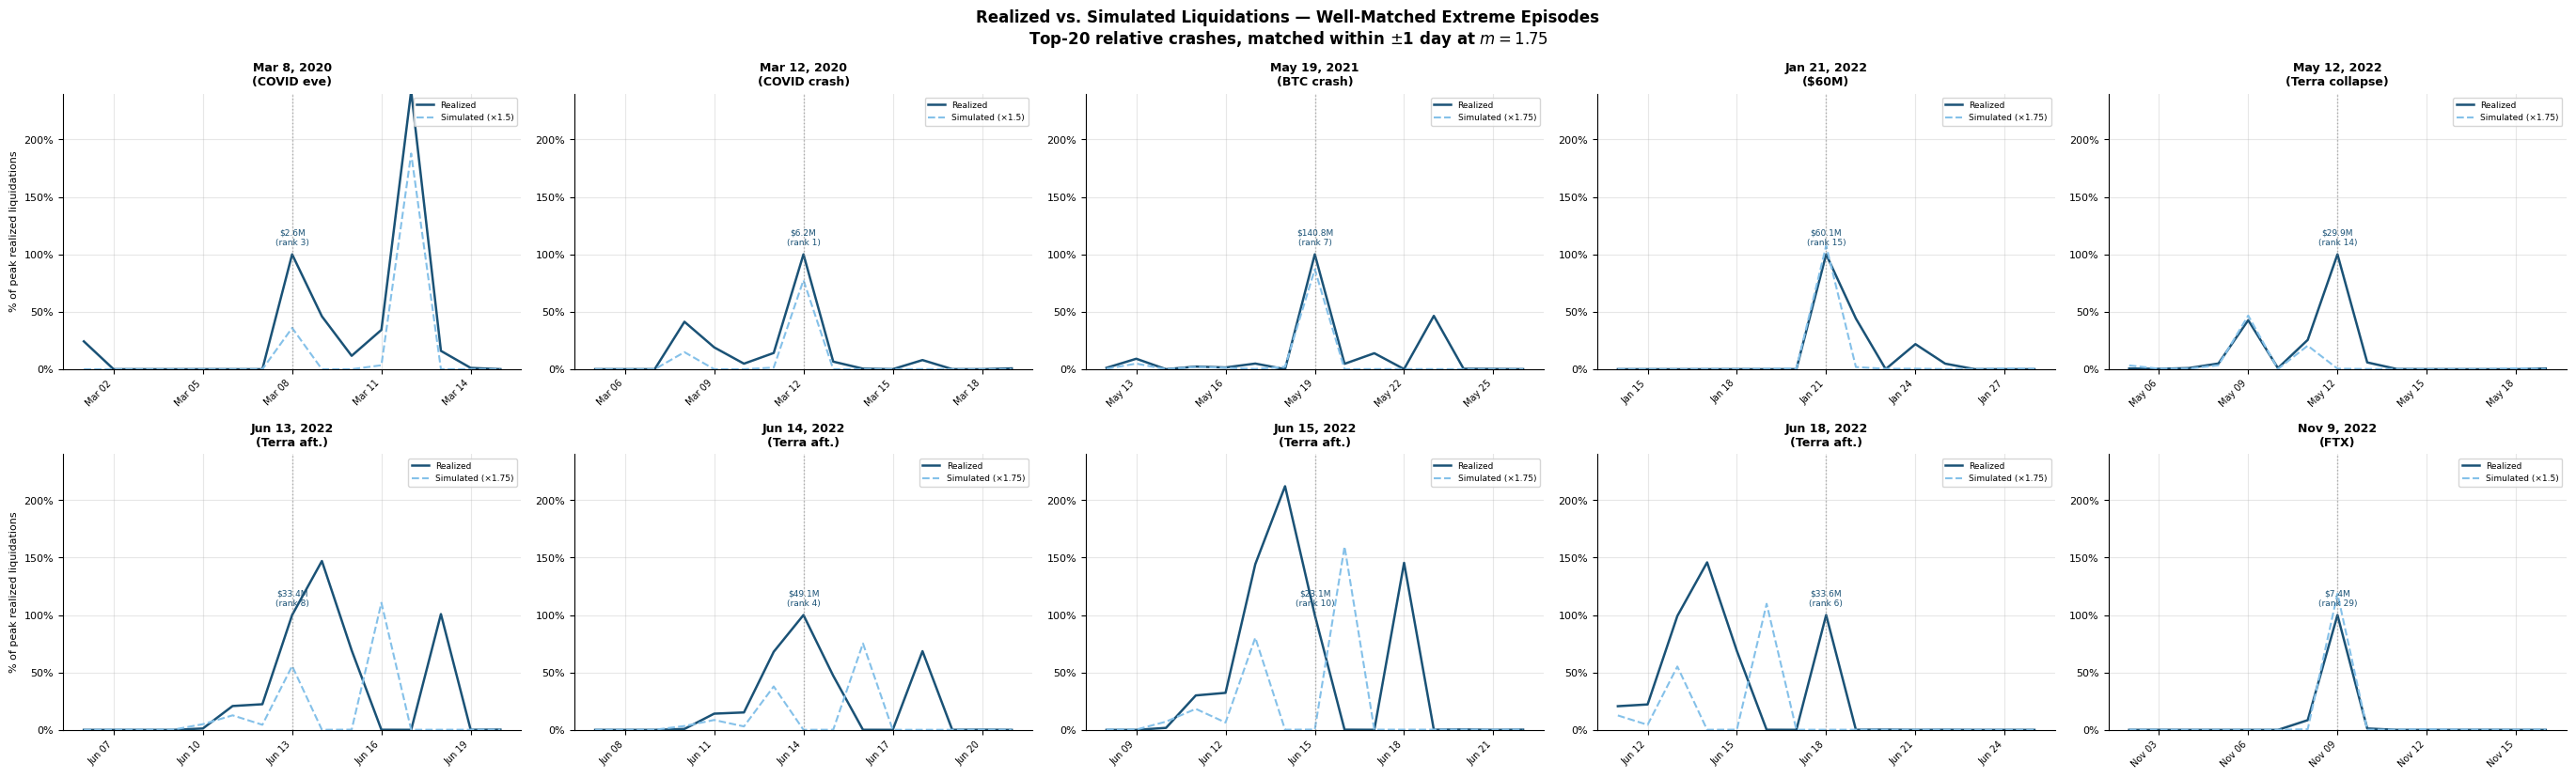

Saved: liquidations_all_matched.pdf  (10 episodes)


In [47]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ══════════════════════════════════════════════════════════════════
# All well-matched extreme episodes from top 20 relative crashes
# Matched at ±0 or ±1 day, mult=1.75, sim_pctile >= 95
# ══════════════════════════════════════════════════════════════════

WINDOW_DAYS = 7
COLOR_REAL  = '#1a5276'   # dark blue — realized
COLOR_SIM   = '#85c1e9'   # light blue — simulated

# All well-matched events (±1 day, ranked by date)
# Format: (peak_date, best_mult, title, rank)
episodes = [
    (pd.Timestamp('2020-03-08'), 1.50, 'Mar 8, 2020\n(COVID eve)',          3),
    (pd.Timestamp('2020-03-12'), 1.50, 'Mar 12, 2020\n(COVID crash)',       1),
    (pd.Timestamp('2021-05-19'), 1.75, 'May 19, 2021\n(BTC crash)',         7),
    (pd.Timestamp('2022-01-21'), 1.75, 'Jan 21, 2022\n($60M)',             15),
    (pd.Timestamp('2022-05-12'), 1.75, 'May 12, 2022\n(Terra collapse)',   14),
    (pd.Timestamp('2022-06-13'), 1.75, 'Jun 13, 2022\n(Terra aft.)',        8),
    (pd.Timestamp('2022-06-14'), 1.75, 'Jun 14, 2022\n(Terra aft.)',        4),
    (pd.Timestamp('2022-06-15'), 1.75, 'Jun 15, 2022\n(Terra aft.)',       10),
    (pd.Timestamp('2022-06-18'), 1.75, 'Jun 18, 2022\n(Terra aft.)',        6),
    (pd.Timestamp('2022-11-09'), 1.50, 'Nov 9, 2022\n(FTX)',               29),
]

n_eps  = len(episodes)
n_cols = 5
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 5.5, n_rows * 4.2))
axes = axes.flatten()

for i, (ax, (peak, mult, title, rank)) in enumerate(
        zip(axes, episodes)):

    # Simulated
    df_m = df_sim_daily[
        df_sim_daily['multiplier'] == mult
    ].sort_values('date')
    df_panel = df_m[
        (df_m['date'] >= peak - pd.Timedelta(days=WINDOW_DAYS)) &
        (df_m['date'] <= peak + pd.Timedelta(days=WINDOW_DAYS))
    ].copy()

    # Realized
    df_real_panel = dr_real[
        (dr_real['date'] >= peak - pd.Timedelta(days=WINDOW_DAYS)) &
        (dr_real['date'] <= peak + pd.Timedelta(days=WINDOW_DAYS))
    ].copy()

    # Normalize by peak realized value
    peak_val = dr_real.loc[
        dr_real['date'] == peak, 'dailyLiquidateUSD'
    ].values
    if len(peak_val) == 0 or peak_val[0] == 0:
        ax.set_visible(False)
        continue
    peak_val = peak_val[0]

    df_panel['liq_pct']       = (
        df_panel['liquidated_nbd'] / peak_val * 100
    )
    df_real_panel['real_pct'] = (
        df_real_panel['dailyLiquidateUSD'] / peak_val * 100
    )

    ax.plot(df_real_panel['date'], df_real_panel['real_pct'],
            color=COLOR_REAL, lw=1.8, label='Realized')
    ax.plot(df_panel['date'], df_panel['liq_pct'],
            color=COLOR_SIM, lw=1.5, ls='--',
            label=f'Simulated (×{mult})')

    ax.axvline(peak, color='gray', ls=':', lw=1, alpha=0.6)
    ax.set_ylim(0, 240)

    # Peak annotation: dollar value and rank
    ax.text(peak, 108,
            f'${peak_val/1e6:.1f}M\n(rank {rank})',
            ha='center', fontsize=6.5, color=COLOR_REAL)

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(),
             rotation=45, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.0f}%')
    )
    ax.tick_params(axis='y', labelsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.legend(fontsize=6.5, loc='upper right')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused panels
for i in range(len(episodes), len(axes)):
    axes[i].set_visible(False)

# Y-labels on left column only
for i in range(0, n_eps, n_cols):
    if i < len(axes):
        axes[i].set_ylabel('% of peak realized liquidations',
                           fontsize=8)

fig.suptitle(
    'Realized vs. Simulated Liquidations — Well-Matched Extreme Episodes\n'
    'Top-20 relative crashes, matched within $\\pm$1 day at $m = 1.75$',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig('liquidations_all_matched.pdf', bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: liquidations_all_matched.pdf  ({n_eps} episodes)')

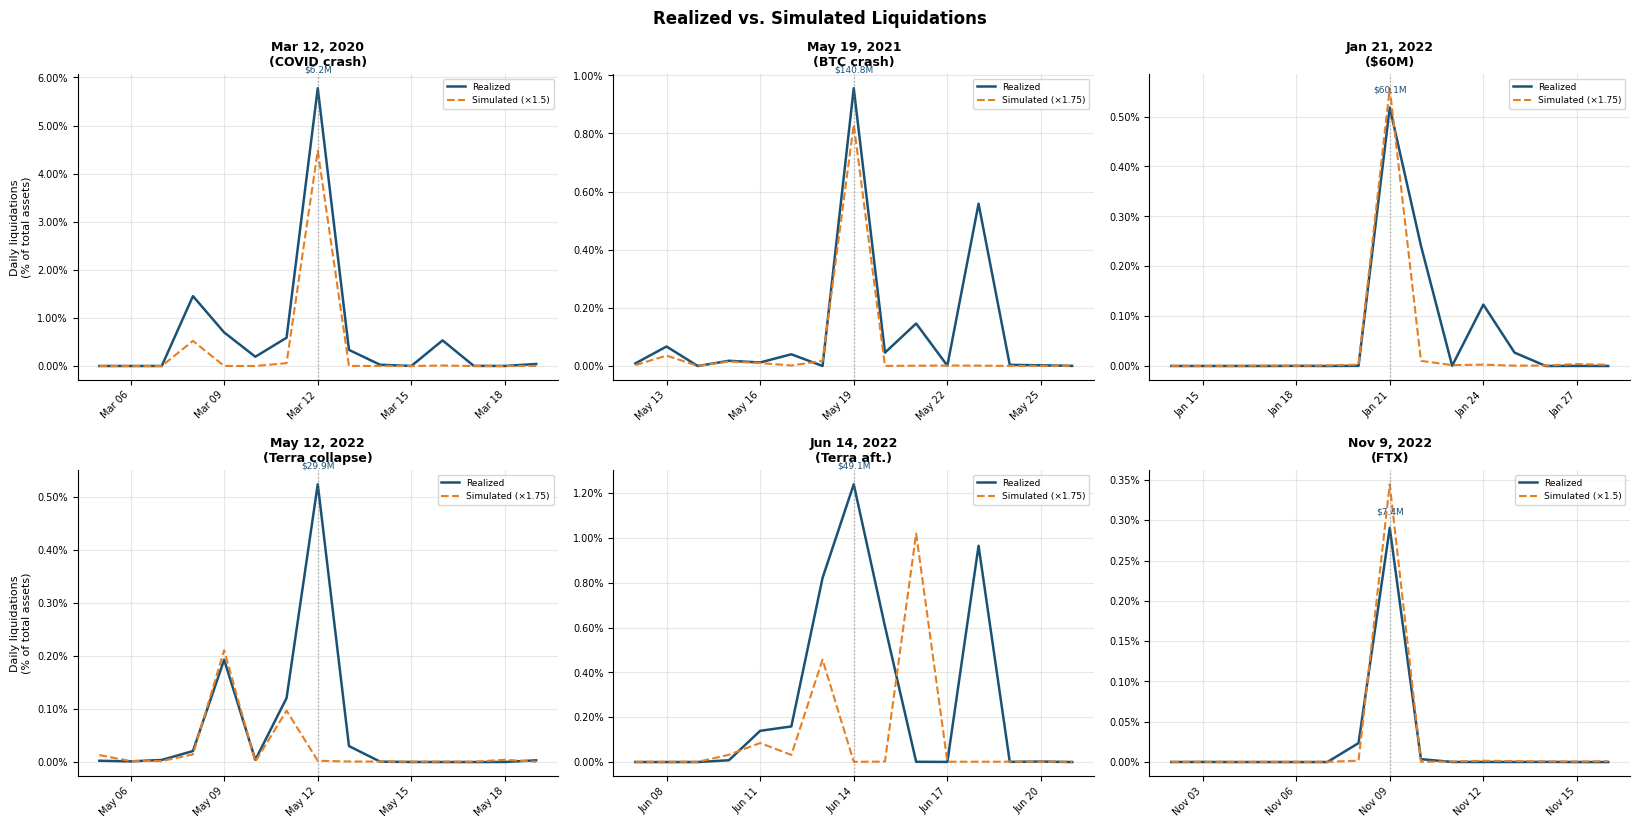

Saved: liquidations_all_matched.pdf  (6 episodes)


In [48]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ══════════════════════════════════════════════════════════════════
# All well-matched extreme episodes from top 20 relative crashes
# Y-axis: liq/TVL ratio (directly comparable across panels)
# ══════════════════════════════════════════════════════════════════

WINDOW_DAYS = 7
COLOR_REAL  = '#1a5276'    # dark blue — realized
COLOR_SIM   = '#e67e22'    # orange — simulated

# Format: (peak_date, best_mult, title, rank)
episodes = [
    (pd.Timestamp('2020-03-12'), 1.50, 'Mar 12, 2020\n(COVID crash)',       1),
    (pd.Timestamp('2021-05-19'), 1.75, 'May 19, 2021\n(BTC crash)',         7),
    (pd.Timestamp('2022-01-21'), 1.75, 'Jan 21, 2022\n($60M)',             15),
    (pd.Timestamp('2022-05-12'), 1.75, 'May 12, 2022\n(Terra collapse)',   14),
    (pd.Timestamp('2022-06-14'), 1.75, 'Jun 14, 2022\n(Terra aft.)',        4),
    (pd.Timestamp('2022-11-09'), 1.50, 'Nov 9, 2022\n(FTX)',               29),
]

n_cols = 3
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 5.5, n_rows * 4.2))
axes = axes.flatten()

# TVL map for simulated normalization
tvl_map = dr_real.set_index('date')['totalValueLockedUSD']

for ax, (peak, mult, title, rank) in zip(axes, episodes):

    # Simulated
    df_m = df_sim_daily[
        df_sim_daily['multiplier'] == mult
    ].sort_values('date')
    df_panel = df_m[
        (df_m['date'] >= peak - pd.Timedelta(days=WINDOW_DAYS)) &
        (df_m['date'] <= peak + pd.Timedelta(days=WINDOW_DAYS))
    ].copy()

    # Realized
    df_real_panel = dr_real[
        (dr_real['date'] >= peak - pd.Timedelta(days=WINDOW_DAYS)) &
        (dr_real['date'] <= peak + pd.Timedelta(days=WINDOW_DAYS))
    ].copy()

    # Check peak exists
    peak_rows = dr_real[dr_real['date'] == peak]
    if len(peak_rows) == 0:
        ax.set_visible(False)
        continue

    peak_liq_M   = peak_rows['dailyLiquidateUSD'].values[0] / 1e6
    peak_liq_tvl = peak_rows['liq_to_tvl'].values[0]

    # Simulated liq/TVL
    df_panel['tvl']     = df_panel['date'].map(tvl_map)
    df_panel['liq_tvl'] = df_panel['liquidated_nbd'] / df_panel['tvl']

    # Realized liq/TVL
    df_real_panel['real_tvl'] = (
        df_real_panel['dailyLiquidateUSD'] /
        df_real_panel['totalValueLockedUSD']
    )

    ax.plot(df_real_panel['date'], df_real_panel['real_tvl'],
            color=COLOR_REAL, lw=1.8, label='Realized')
    ax.plot(df_panel['date'], df_panel['liq_tvl'],
            color=COLOR_SIM, lw=1.5, ls='--',
            label=f'Simulated (×{mult})')

    ax.axvline(peak, color='gray', ls=':', lw=1, alpha=0.6)

    # Annotation: peak dollar value
    ax.text(peak, peak_liq_tvl * 1.05,
            f'${peak_liq_M:.1f}M',
            ha='center', fontsize=6.5, color=COLOR_REAL,
            va='bottom')

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x*100:.2f}%')
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(),
             rotation=45, ha='right', fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.legend(fontsize=6.5, loc='upper right')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused panels
for i in range(len(episodes), len(axes)):
    axes[i].set_visible(False)

# Y-labels on left column only
for i in range(0, len(episodes), n_cols):
    if i < len(axes):
        axes[i].set_ylabel('Daily liquidations\n(% of total assets)', fontsize=8)

fig.suptitle(
    'Realized vs. Simulated Liquidations',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig('liquidations_all_matched.pdf', bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: liquidations_all_matched.pdf  ({len(episodes)} episodes)')

In [49]:
for peak, label in [
    (pd.Timestamp('2022-01-22'), 'Jan 22, 2022'),
    (pd.Timestamp('2021-05-23'), 'May 23, 2021'),
    (pd.Timestamp('2022-05-11'), 'May 11, 2022'),
    (pd.Timestamp('2022-05-13'), 'May 13, 2022'),
]:
    print(f"\n{label}")
    for mult in [1.50, 1.75]:
        df_m     = df_sim_daily[df_sim_daily['multiplier'] == mult].sort_values('date')
        row      = df_m[df_m['date'] == peak]
        real_row = dr_real[dr_real['date'] == peak]
        if len(row) > 0 and len(real_row) > 0:
            sim_val    = row['liq_to_tvl_sim'].values[0]
            real_val   = real_row['liq_to_tvl'].values[0]
            sim_pctile = (df_m['liq_to_tvl_sim'] <= sim_val).mean() * 100
            liq_M      = real_row['dailyLiquidateUSD'].values[0]/1e6
            print(f"  mult={mult}  liq=${liq_M:.1f}M  "
                  f"sim/real={sim_val/real_val*100:.1f}%  "
                  f"sim_pctile={sim_pctile:.1f}")


Jan 22, 2022
  mult=1.5  liq=$26.5M  sim/real=1.6%  sim_pctile=90.8
  mult=1.75  liq=$26.5M  sim/real=4.3%  sim_pctile=95.6

May 23, 2021
  mult=1.5  liq=$65.4M  sim/real=0.1%  sim_pctile=51.6
  mult=1.75  liq=$65.4M  sim/real=0.2%  sim_pctile=69.6

May 11, 2022
  mult=1.5  liq=$7.6M  sim/real=18.0%  sim_pctile=98.6
  mult=1.75  liq=$7.6M  sim/real=80.3%  sim_pctile=99.0

May 13, 2022
  mult=1.5  liq=$1.8M  sim/real=3.6%  sim_pctile=70.2
  mult=1.75  liq=$1.8M  sim/real=3.3%  sim_pctile=62.6


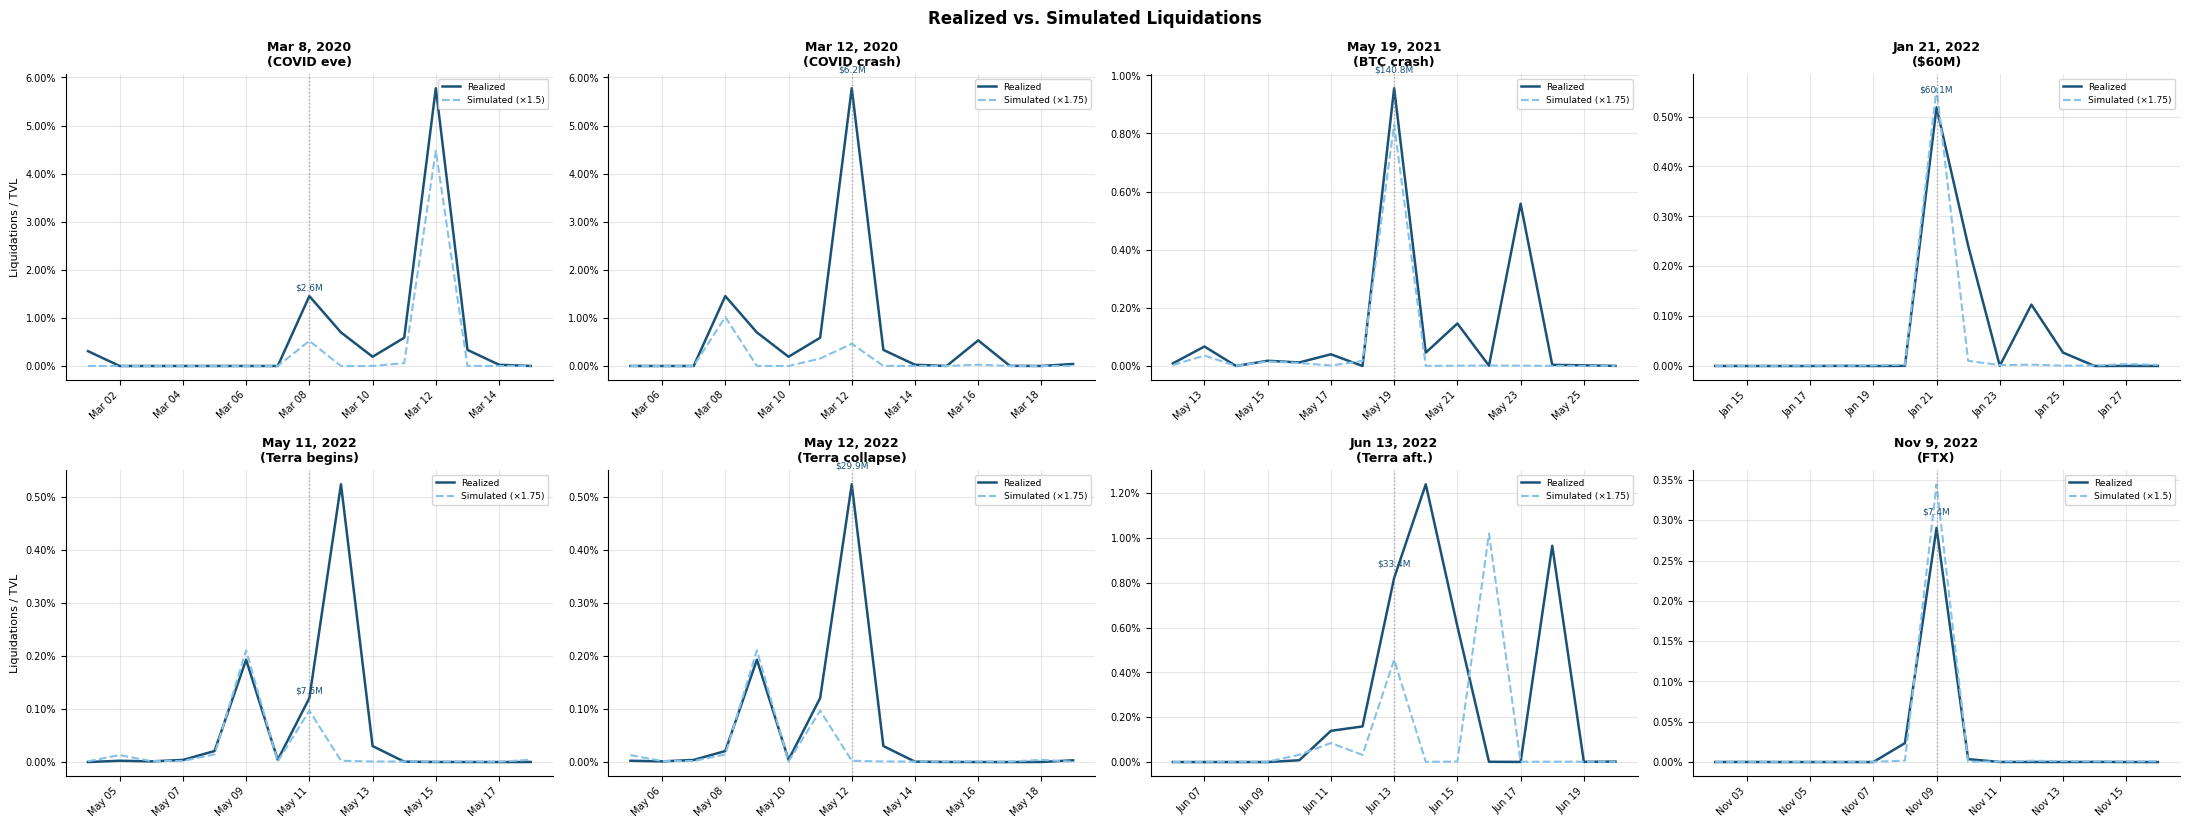

Saved: liquidations_all_matched.pdf  (8 episodes)


In [50]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import numpy as np

# ══════════════════════════════════════════════════════════════════
# All well-matched extreme episodes — fixed version
# - Mar 12 2020: mult=1.75 (better match)
# - Terra panels: ±4 day window (more distinct)
# ══════════════════════════════════════════════════════════════════

COLOR_REAL = '#1a5276'   # dark blue — realized
COLOR_SIM  = '#85c1e9'   # light blue — simulated

# Format: (peak_date, best_mult, title, rank, window_days)
episodes = [
    (pd.Timestamp('2020-03-08'), 1.50, 'Mar 8, 2020\n(COVID eve)',        3,  7),
    (pd.Timestamp('2020-03-12'), 1.75, 'Mar 12, 2020\n(COVID crash)',     1,  7),
    (pd.Timestamp('2021-05-19'), 1.75, 'May 19, 2021\n(BTC crash)',       7,  7),
    (pd.Timestamp('2022-01-21'), 1.75, 'Jan 21, 2022\n($60M)',           15,  7),
    (pd.Timestamp('2022-05-11'), 1.75, 'May 11, 2022\n(Terra begins)',   14,  7),
    (pd.Timestamp('2022-05-12'), 1.75, 'May 12, 2022\n(Terra collapse)', 14,  7),
    (pd.Timestamp('2022-06-13'), 1.75, 'Jun 13, 2022\n(Terra aft.)',      8,  7),
    (pd.Timestamp('2022-11-09'), 1.50, 'Nov 9, 2022\n(FTX)',             29,  7),
]

n_cols = 4
n_rows = 2

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 5.5, n_rows * 4.2))
axes = axes.flatten()

# TVL map for simulated normalization
tvl_map = dr_real.set_index('date')['totalValueLockedUSD']

for ax, (peak, mult, title, rank, window) in zip(axes, episodes):

    # Simulated
    df_m = df_sim_daily[
        df_sim_daily['multiplier'] == mult
    ].sort_values('date')
    df_panel = df_m[
        (df_m['date'] >= peak - pd.Timedelta(days=window)) &
        (df_m['date'] <= peak + pd.Timedelta(days=window))
    ].copy()

    # Realized
    df_real_panel = dr_real[
        (dr_real['date'] >= peak - pd.Timedelta(days=window)) &
        (dr_real['date'] <= peak + pd.Timedelta(days=window))
    ].copy()

    # Check peak exists
    peak_rows = dr_real[dr_real['date'] == peak]
    if len(peak_rows) == 0:
        ax.set_visible(False)
        continue

    peak_liq_M   = peak_rows['dailyLiquidateUSD'].values[0] / 1e6
    peak_liq_tvl = peak_rows['liq_to_tvl'].values[0]

    # Simulated liq/TVL
    df_panel['tvl']     = df_panel['date'].map(tvl_map)
    df_panel['liq_tvl'] = df_panel['liquidated_nbd'] / df_panel['tvl']

    # Realized liq/TVL
    df_real_panel['real_tvl'] = (
        df_real_panel['dailyLiquidateUSD'] /
        df_real_panel['totalValueLockedUSD']
    )

    ax.plot(df_real_panel['date'], df_real_panel['real_tvl'],
            color=COLOR_REAL, lw=1.8, label='Realized')
    ax.plot(df_panel['date'], df_panel['liq_tvl'],
            color=COLOR_SIM, lw=1.5, ls='--',
            label=f'Simulated (×{mult})')

    ax.axvline(peak, color='gray', ls=':', lw=1, alpha=0.6)

    # Annotation: peak dollar value
    ax.text(peak, peak_liq_tvl * 1.05,
            f'${peak_liq_M:.1f}M',
            ha='center', fontsize=6.5, color=COLOR_REAL,
            va='bottom')

    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x*100:.2f}%')
    )
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(),
             rotation=45, ha='right', fontsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.legend(fontsize=6.5, loc='upper right')
    ax.grid(alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Hide unused panels
for i in range(len(episodes), len(axes)):
    axes[i].set_visible(False)

# Y-labels on left column only
for i in range(0, len(episodes), n_cols):
    if i < len(axes):
        axes[i].set_ylabel('Liquidations / TVL', fontsize=8)

fig.suptitle(
    'Realized vs. Simulated Liquidations',
    fontsize=12, fontweight='bold'
)

plt.tight_layout()
plt.savefig('liquidations_all_matched.pdf', bbox_inches='tight', dpi=150)
plt.show()
print(f'Saved: liquidations_all_matched.pdf  ({len(episodes)} episodes)')